In [59]:
!nvidia-smi


Fri Apr 10 11:49:21 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.126.09             Driver Version: 580.126.09     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 5070 ...    Off |   00000000:64:00.0  On |                  N/A |
| N/A   51C    P4              7W /   50W |    1291MiB /   8151MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [60]:
# --- cell 2 --- TOUJOURS EN PREMIER avant tout import jax
import os, sys
sys.path.append("../../")

# GPU config — DOIT être avant import jax
os.environ['CUDA_DEVICE_ORDER']              = 'PCI_BUS_ID'
os.environ['CUDA_VISIBLE_DEVICES']           = '0'
os.environ['XLA_PYTHON_CLIENT_PREALLOCATE']  = 'false'   # ← clé manquante
#os.environ['XLA_PYTHON_CLIENT_MEM_FRACTION'] = '0.7'     # limite à 70% VRAM

import jax
import jax.numpy as jnp

jax.config.update('jax_disable_jit', False)
jax.config.update('jax_debug_nans', False)

print("Backend :", jax.default_backend())
print("Devices :", jax.devices())

Backend : gpu
Devices : [CudaDevice(id=0)]


In [61]:
import diffhydro as dh


eq = dh.equationmanager.EquationManager()
eq.mesh_shape=[100,100,100] #max 205

In [62]:
U = dh.turbulence.init_turbulent_velocity(eq, 100, 1.0, 1.0,kmax=10,seed=123)#seed=123

%pylab is deprecated, use %matplotlib inline and import the required libraries.
Populating the interactive namespace from numpy and matplotlib


/home/stoike/miniconda3/envs/jax-gpu/lib/python3.11/site-packages/IPython/core/magics/pylab.py:166: UserWarning: pylab import has clobbered these variables: ['copy']
`%matplotlib` prevents importing * from pylab and numpy
  warn("pylab import has clobbered these variables: %s"  % clobbered +


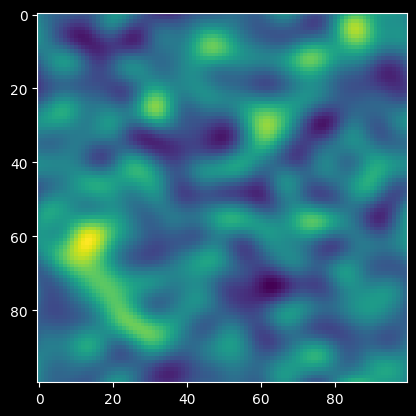

In [63]:
%pylab inline
imshow(U[3][30])

In [64]:
eq.cfl = 0.3
ss = dh.signal_speed_Rusanov

solver = dh.LaxFriedrichs(equation_manager=eq,signal_speed=ss)
grav = dh.physics.gravity.FFTSelfGravityForce(eq, G=6E-4, subtract_mean=True)  

cf = dh.ConvectiveFlux(eq,solver,dh.MUSCL3(limiter="VANLEER"),positivity=False)
#ct = dh.mhd.ConstrainedTransportFlux(eq, solver, dh.MUSCL3(limiter="MINMOD"), positivity=False)

hydro = dh.hydro(n_super_step=2000, fluxes=[cf],forces=[grav],
                 use_mol=True, integrator="RK4",
                 snapshot_every=50,snapshot_dir="turb_collapse_big2",snapshot_prefix="RK4",pmesh_shape=(1,1,1)) 
                 
                 

In [65]:
import copy
params = {}
output = hydro.evolve_with_callbacks(copy.deepcopy(U),params)

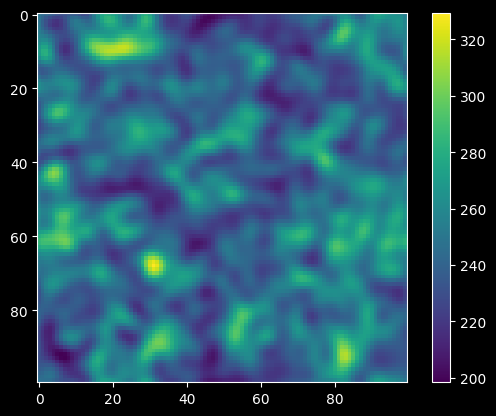

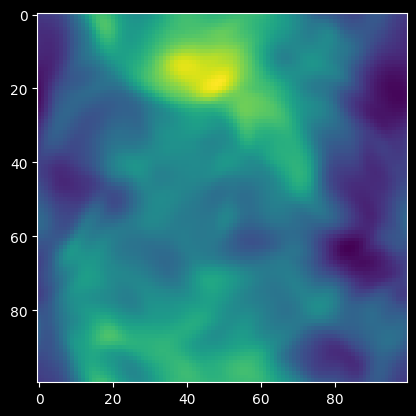

In [66]:
imshow(U[-1].sum(axis=0))
colorbar()
show()
imshow(output[0][0][30])
show()

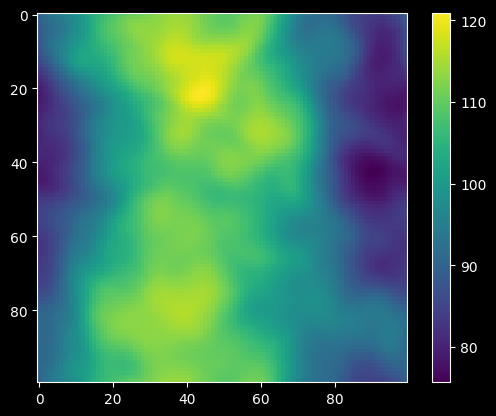

In [67]:
imshow(output[0][0].sum(axis=0))
colorbar()

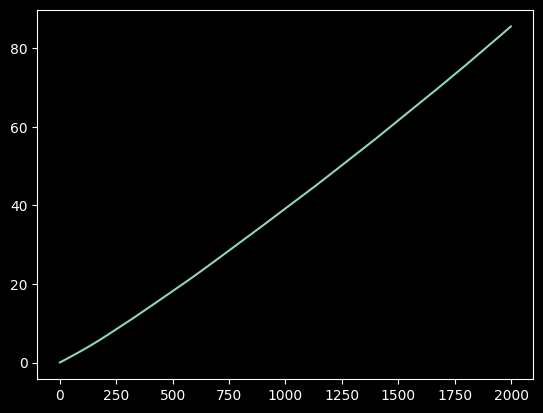

In [68]:
plt.plot(np.cumsum(output[-1]))

Shard shape: (5, 100, 100, 100)
Partition spec: P(None, 'x', 'y', 'z')
Axis mapping: {'x': 1, 'y': 2, 'z': 3}


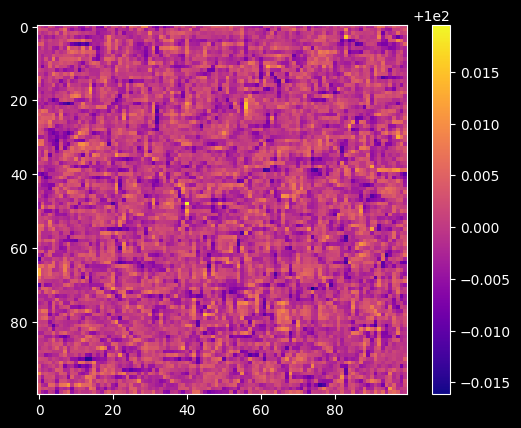

Shard shape: (5, 100, 100, 100)
Partition spec: P(None, 'x', 'y', 'z')
Axis mapping: {'x': 1, 'y': 2, 'z': 3}


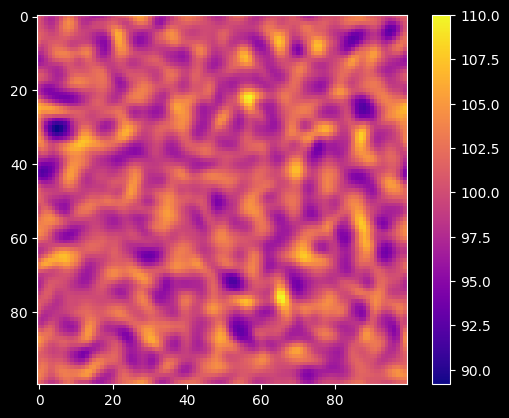

Shard shape: (5, 100, 100, 100)
Partition spec: P(None, 'x', 'y', 'z')
Axis mapping: {'x': 1, 'y': 2, 'z': 3}


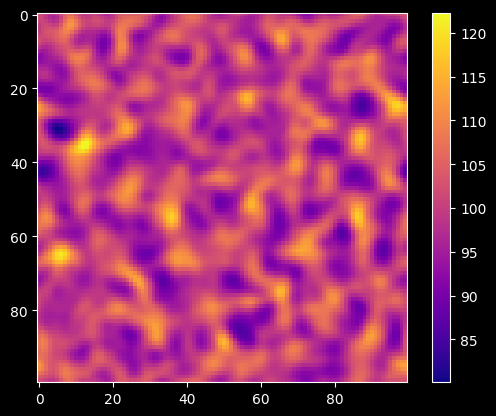

Shard shape: (5, 100, 100, 100)
Partition spec: P(None, 'x', 'y', 'z')
Axis mapping: {'x': 1, 'y': 2, 'z': 3}


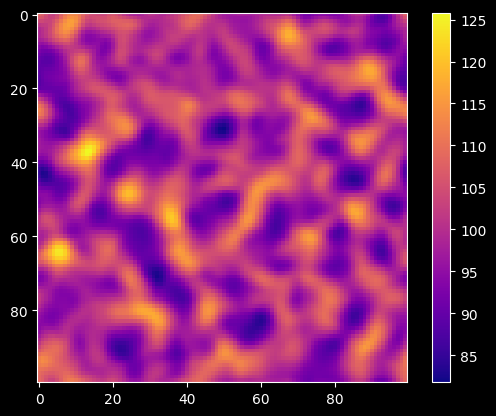

Shard shape: (5, 100, 100, 100)
Partition spec: P(None, 'x', 'y', 'z')
Axis mapping: {'x': 1, 'y': 2, 'z': 3}


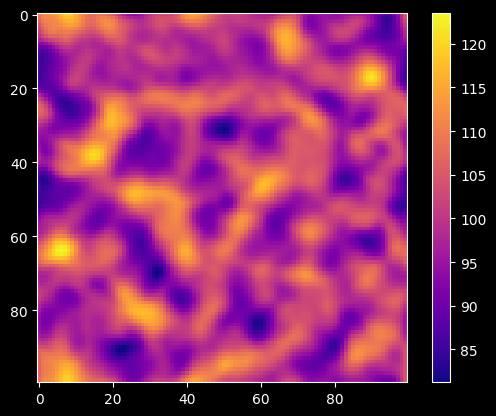

Shard shape: (5, 100, 100, 100)
Partition spec: P(None, 'x', 'y', 'z')
Axis mapping: {'x': 1, 'y': 2, 'z': 3}


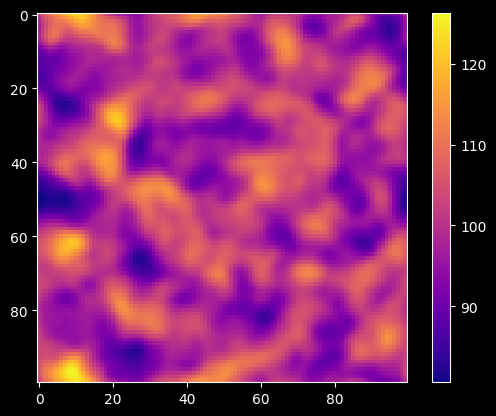

Shard shape: (5, 100, 100, 100)
Partition spec: P(None, 'x', 'y', 'z')
Axis mapping: {'x': 1, 'y': 2, 'z': 3}


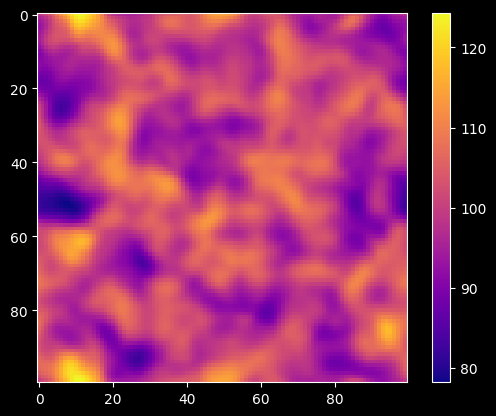

Shard shape: (5, 100, 100, 100)
Partition spec: P(None, 'x', 'y', 'z')
Axis mapping: {'x': 1, 'y': 2, 'z': 3}


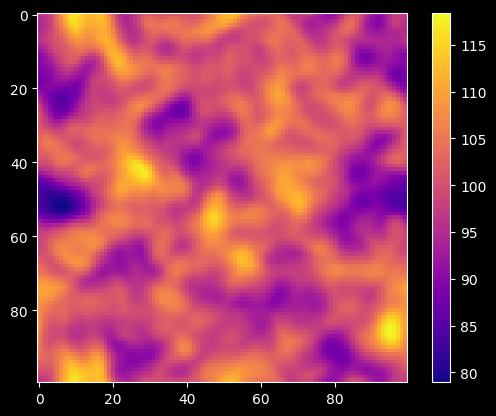

Shard shape: (5, 100, 100, 100)
Partition spec: P(None, 'x', 'y', 'z')
Axis mapping: {'x': 1, 'y': 2, 'z': 3}


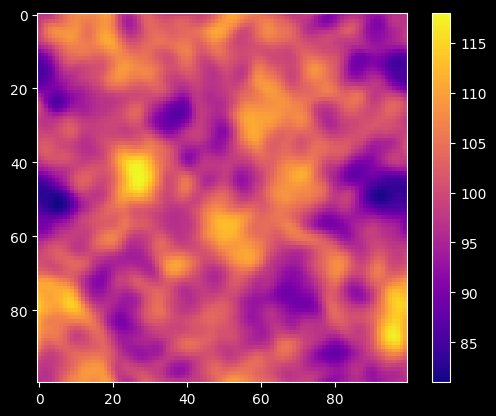

Shard shape: (5, 100, 100, 100)
Partition spec: P(None, 'x', 'y', 'z')
Axis mapping: {'x': 1, 'y': 2, 'z': 3}


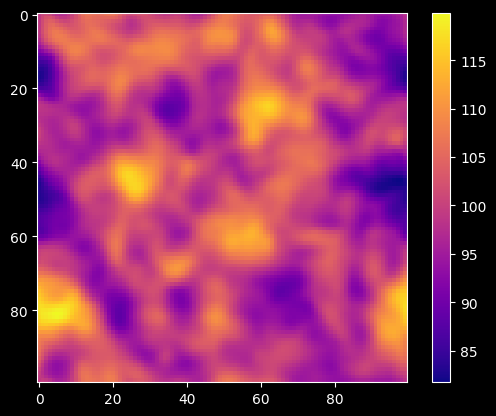

Shard shape: (5, 100, 100, 100)
Partition spec: P(None, 'x', 'y', 'z')
Axis mapping: {'x': 1, 'y': 2, 'z': 3}


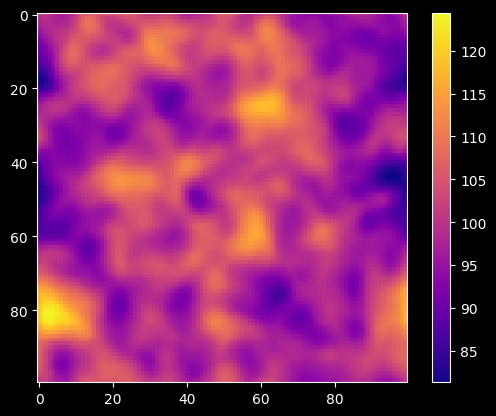

Shard shape: (5, 100, 100, 100)
Partition spec: P(None, 'x', 'y', 'z')
Axis mapping: {'x': 1, 'y': 2, 'z': 3}


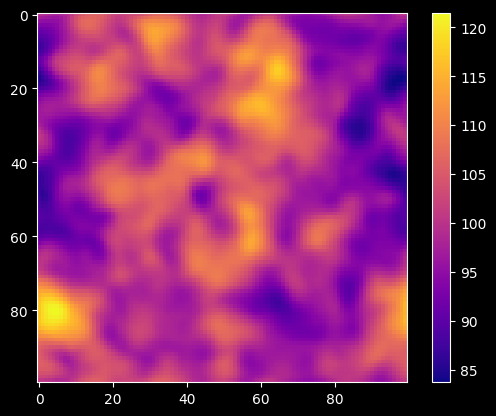

Shard shape: (5, 100, 100, 100)
Partition spec: P(None, 'x', 'y', 'z')
Axis mapping: {'x': 1, 'y': 2, 'z': 3}


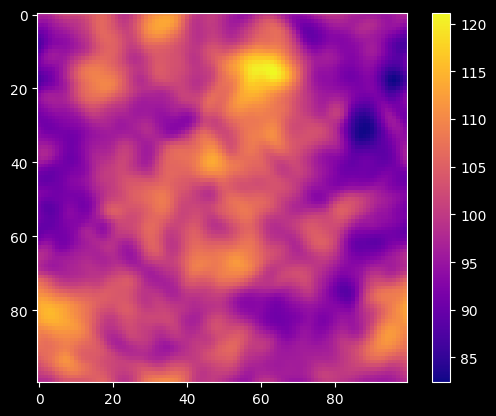

Shard shape: (5, 100, 100, 100)
Partition spec: P(None, 'x', 'y', 'z')
Axis mapping: {'x': 1, 'y': 2, 'z': 3}


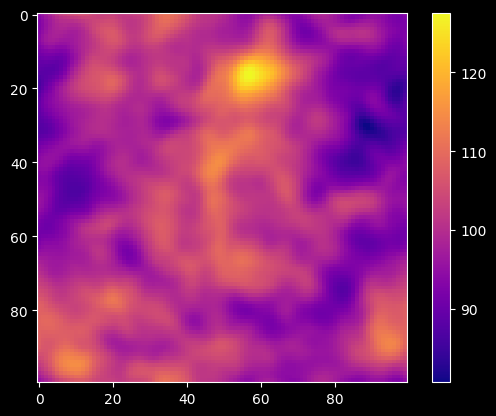

Shard shape: (5, 100, 100, 100)
Partition spec: P(None, 'x', 'y', 'z')
Axis mapping: {'x': 1, 'y': 2, 'z': 3}


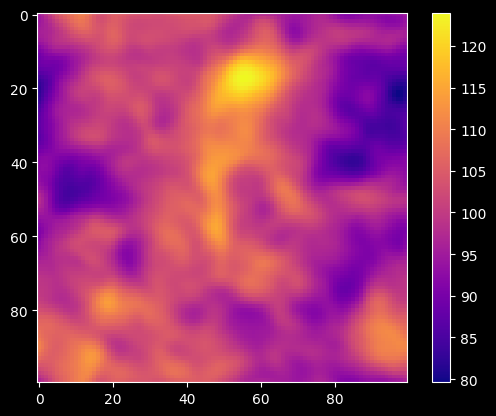

Shard shape: (5, 100, 100, 100)
Partition spec: P(None, 'x', 'y', 'z')
Axis mapping: {'x': 1, 'y': 2, 'z': 3}


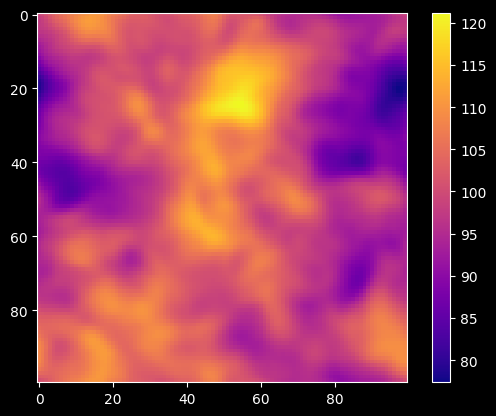

Shard shape: (5, 100, 100, 100)
Partition spec: P(None, 'x', 'y', 'z')
Axis mapping: {'x': 1, 'y': 2, 'z': 3}


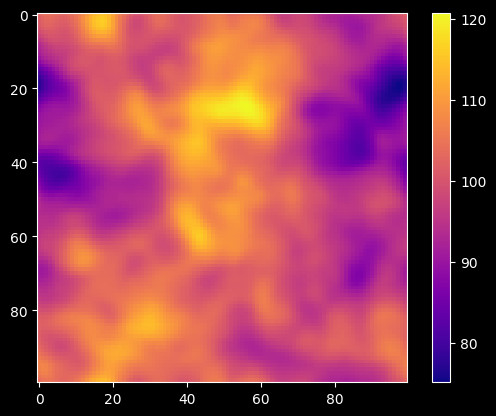

Shard shape: (5, 100, 100, 100)
Partition spec: P(None, 'x', 'y', 'z')
Axis mapping: {'x': 1, 'y': 2, 'z': 3}


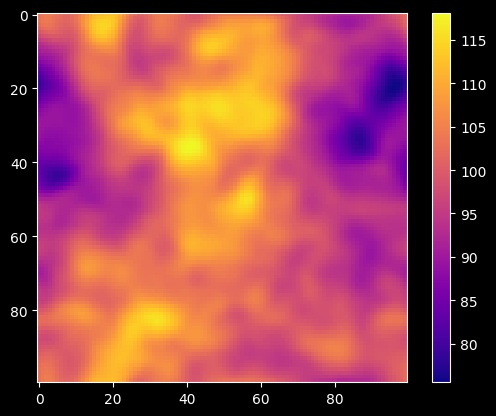

Shard shape: (5, 100, 100, 100)
Partition spec: P(None, 'x', 'y', 'z')
Axis mapping: {'x': 1, 'y': 2, 'z': 3}


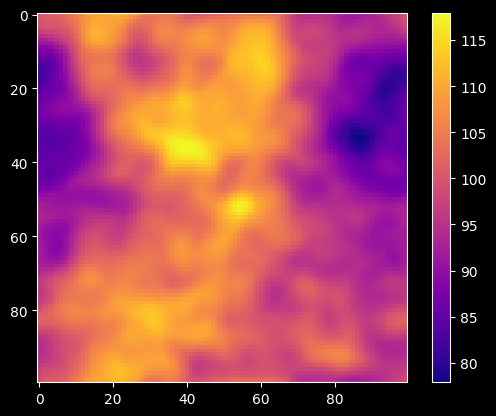

Shard shape: (5, 100, 100, 100)
Partition spec: P(None, 'x', 'y', 'z')
Axis mapping: {'x': 1, 'y': 2, 'z': 3}


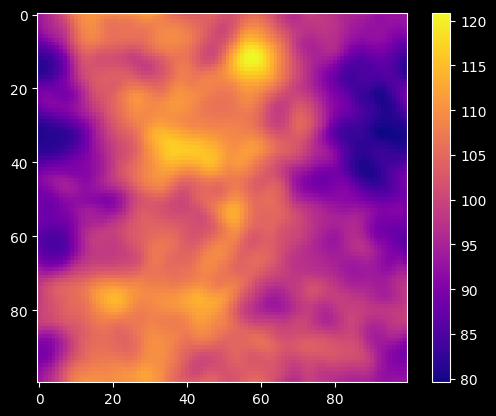

Shard shape: (5, 100, 100, 100)
Partition spec: P(None, 'x', 'y', 'z')
Axis mapping: {'x': 1, 'y': 2, 'z': 3}


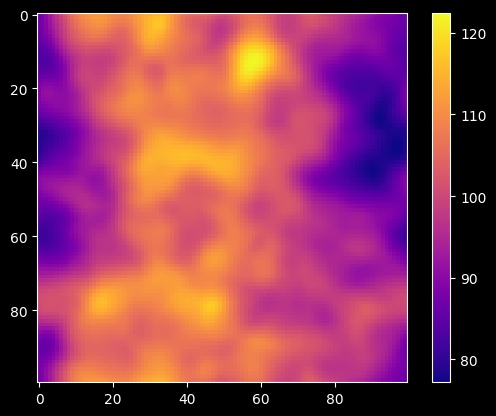

Shard shape: (5, 100, 100, 100)
Partition spec: P(None, 'x', 'y', 'z')
Axis mapping: {'x': 1, 'y': 2, 'z': 3}


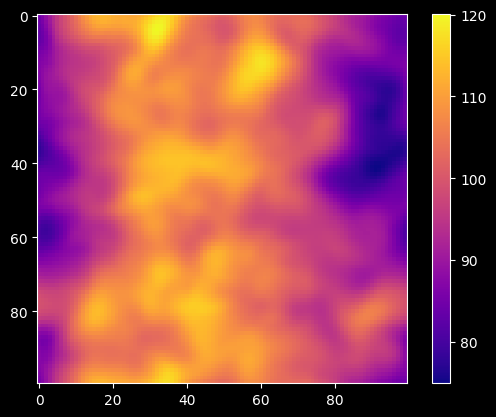

Shard shape: (5, 100, 100, 100)
Partition spec: P(None, 'x', 'y', 'z')
Axis mapping: {'x': 1, 'y': 2, 'z': 3}


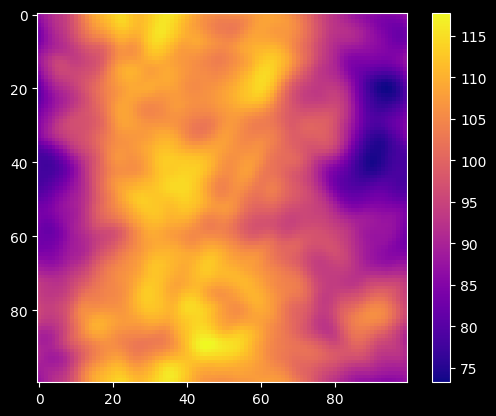

Shard shape: (5, 100, 100, 100)
Partition spec: P(None, 'x', 'y', 'z')
Axis mapping: {'x': 1, 'y': 2, 'z': 3}


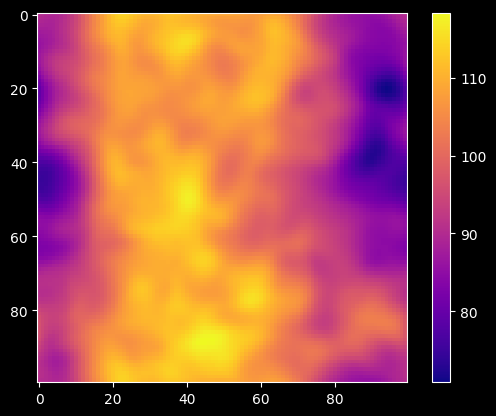

Shard shape: (5, 100, 100, 100)
Partition spec: P(None, 'x', 'y', 'z')
Axis mapping: {'x': 1, 'y': 2, 'z': 3}


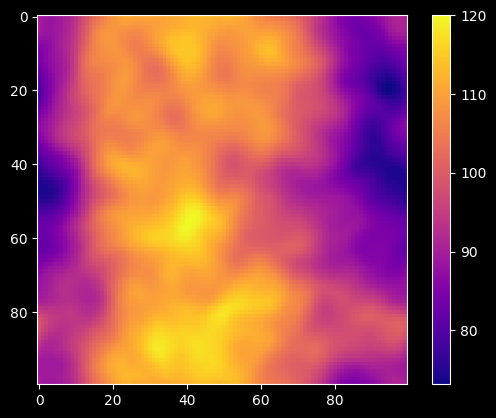

Shard shape: (5, 100, 100, 100)
Partition spec: P(None, 'x', 'y', 'z')
Axis mapping: {'x': 1, 'y': 2, 'z': 3}


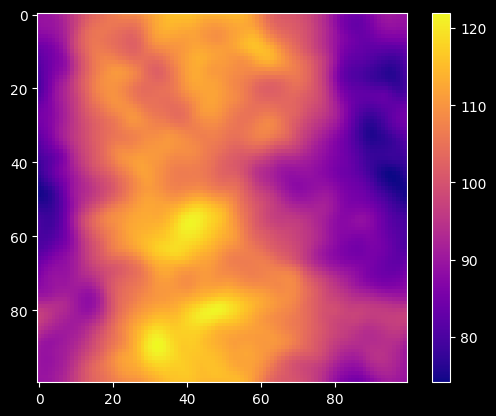

Shard shape: (5, 100, 100, 100)
Partition spec: P(None, 'x', 'y', 'z')
Axis mapping: {'x': 1, 'y': 2, 'z': 3}


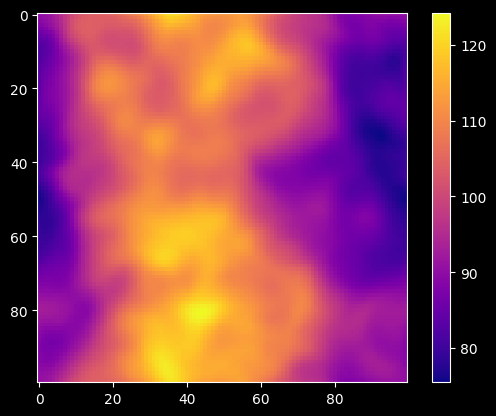

Shard shape: (5, 100, 100, 100)
Partition spec: P(None, 'x', 'y', 'z')
Axis mapping: {'x': 1, 'y': 2, 'z': 3}


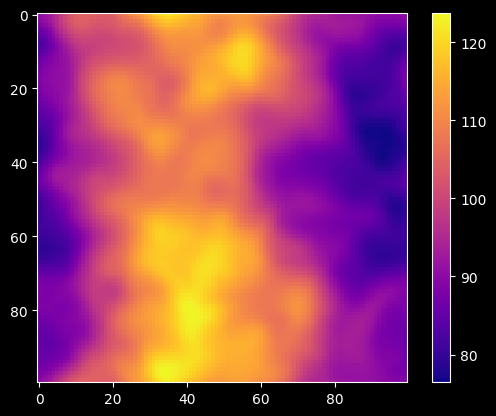

Shard shape: (5, 100, 100, 100)
Partition spec: P(None, 'x', 'y', 'z')
Axis mapping: {'x': 1, 'y': 2, 'z': 3}


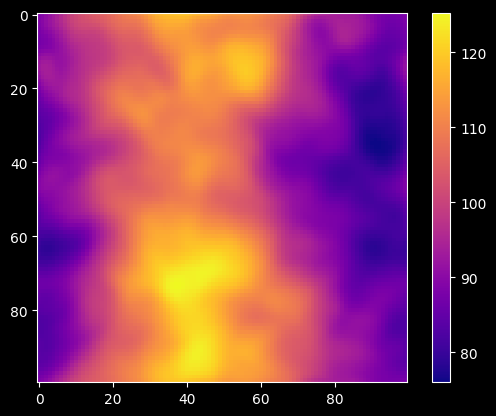

Shard shape: (5, 100, 100, 100)
Partition spec: P(None, 'x', 'y', 'z')
Axis mapping: {'x': 1, 'y': 2, 'z': 3}


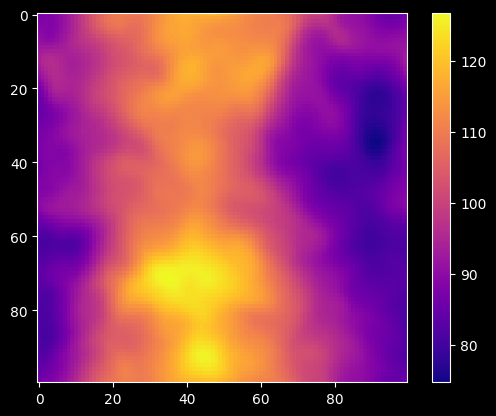

Shard shape: (5, 100, 100, 100)
Partition spec: P(None, 'x', 'y', 'z')
Axis mapping: {'x': 1, 'y': 2, 'z': 3}


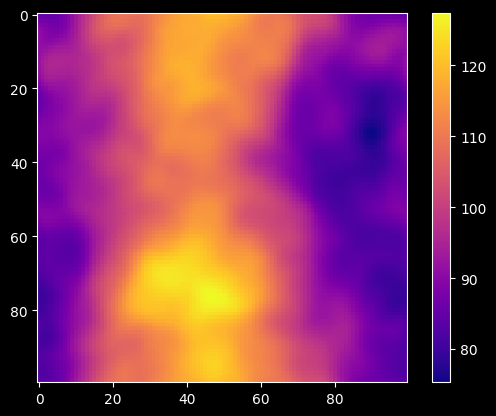

Shard shape: (5, 100, 100, 100)
Partition spec: P(None, 'x', 'y', 'z')
Axis mapping: {'x': 1, 'y': 2, 'z': 3}


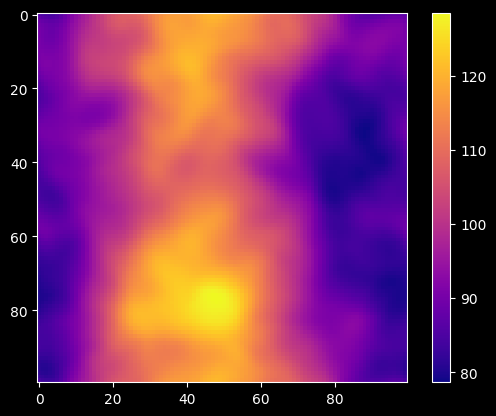

Shard shape: (5, 100, 100, 100)
Partition spec: P(None, 'x', 'y', 'z')
Axis mapping: {'x': 1, 'y': 2, 'z': 3}


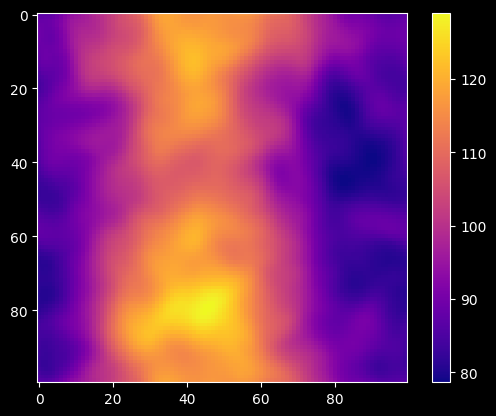

Shard shape: (5, 100, 100, 100)
Partition spec: P(None, 'x', 'y', 'z')
Axis mapping: {'x': 1, 'y': 2, 'z': 3}


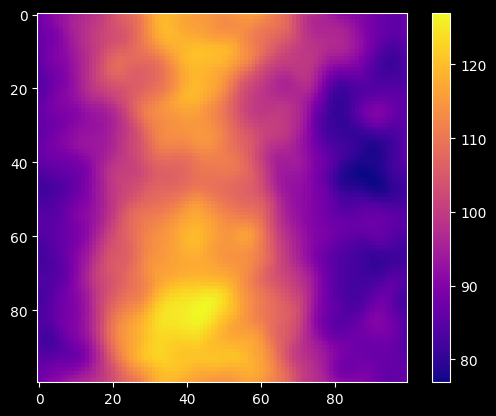

Shard shape: (5, 100, 100, 100)
Partition spec: P(None, 'x', 'y', 'z')
Axis mapping: {'x': 1, 'y': 2, 'z': 3}


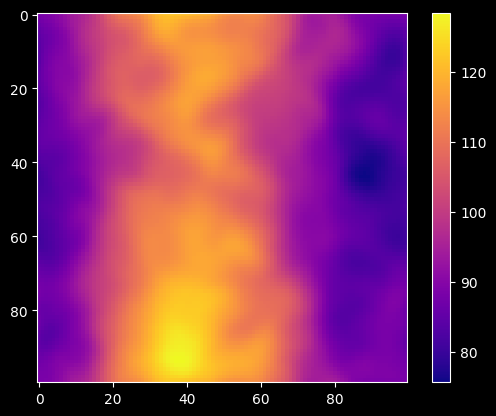

Shard shape: (5, 100, 100, 100)
Partition spec: P(None, 'x', 'y', 'z')
Axis mapping: {'x': 1, 'y': 2, 'z': 3}


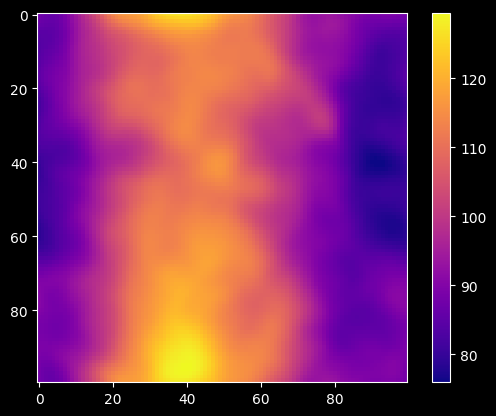

Shard shape: (5, 100, 100, 100)
Partition spec: P(None, 'x', 'y', 'z')
Axis mapping: {'x': 1, 'y': 2, 'z': 3}


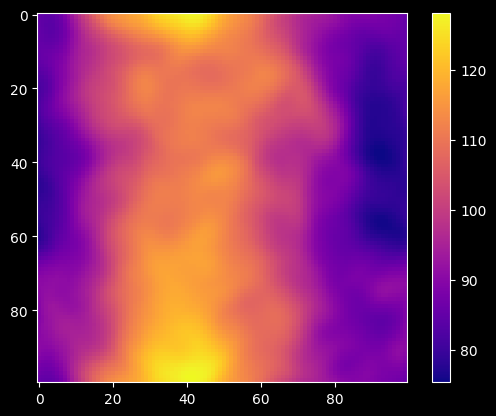

Shard shape: (5, 100, 100, 100)
Partition spec: P(None, 'x', 'y', 'z')
Axis mapping: {'x': 1, 'y': 2, 'z': 3}


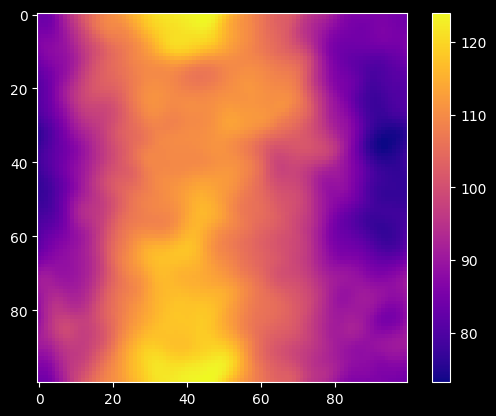

Shard shape: (5, 100, 100, 100)
Partition spec: P(None, 'x', 'y', 'z')
Axis mapping: {'x': 1, 'y': 2, 'z': 3}


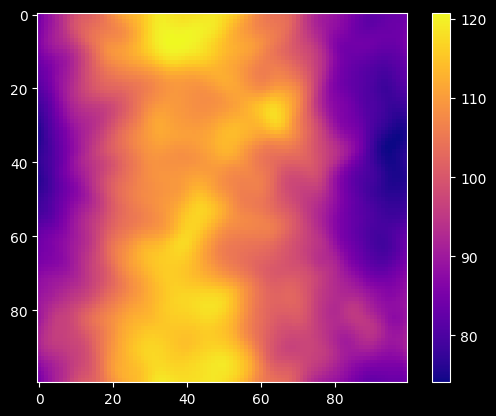

Shard shape: (5, 100, 100, 100)
Partition spec: P(None, 'x', 'y', 'z')
Axis mapping: {'x': 1, 'y': 2, 'z': 3}


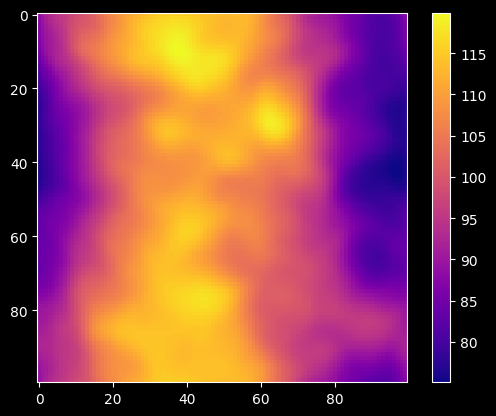

In [69]:
from diffhydro.utils.io import shard_snaps

# Charger tous les 50 steps (matching snapshot_every=50)
for i in range(0, 2000, 50):  # ← Changed from 250 to 50
    imshow(shard_snaps.load_snapshot(hydro, i)[0].sum(axis=0), cmap="plasma")
    colorbar()
    show()

Shard shape: (5, 100, 100, 100)
Partition spec: P(None, 'x', 'y', 'z')
Axis mapping: {'x': 1, 'y': 2, 'z': 3}


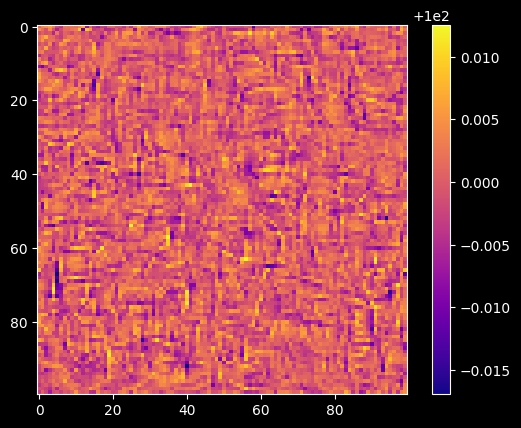

Shard shape: (5, 100, 100, 100)
Partition spec: P(None, 'x', 'y', 'z')
Axis mapping: {'x': 1, 'y': 2, 'z': 3}


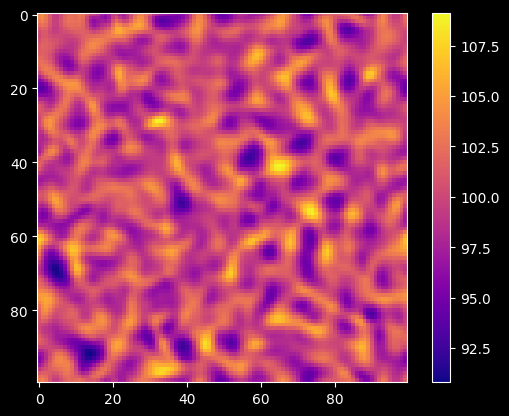

Shard shape: (5, 100, 100, 100)
Partition spec: P(None, 'x', 'y', 'z')
Axis mapping: {'x': 1, 'y': 2, 'z': 3}


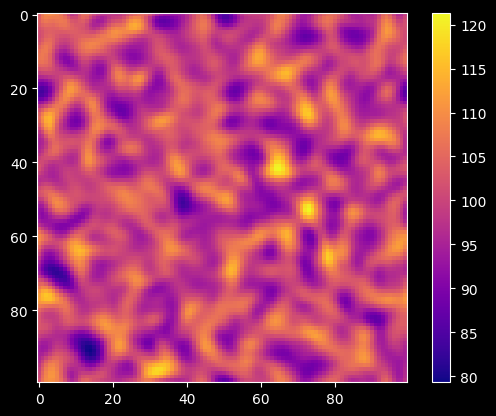

Shard shape: (5, 100, 100, 100)
Partition spec: P(None, 'x', 'y', 'z')
Axis mapping: {'x': 1, 'y': 2, 'z': 3}


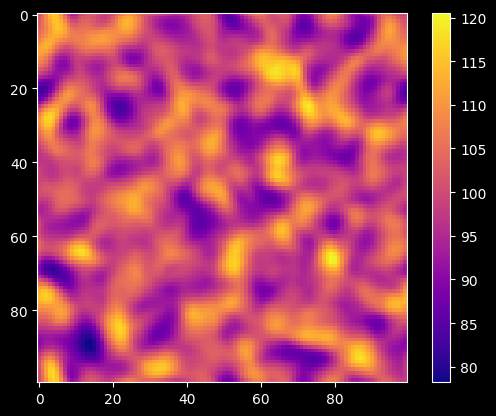

Shard shape: (5, 100, 100, 100)
Partition spec: P(None, 'x', 'y', 'z')
Axis mapping: {'x': 1, 'y': 2, 'z': 3}


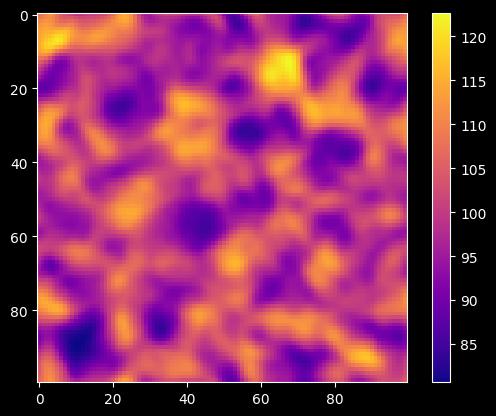

Shard shape: (5, 100, 100, 100)
Partition spec: P(None, 'x', 'y', 'z')
Axis mapping: {'x': 1, 'y': 2, 'z': 3}


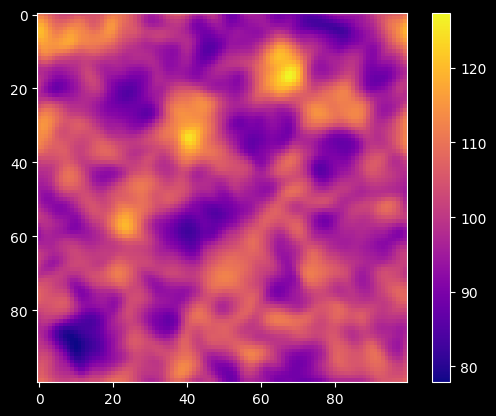

Shard shape: (5, 100, 100, 100)
Partition spec: P(None, 'x', 'y', 'z')
Axis mapping: {'x': 1, 'y': 2, 'z': 3}


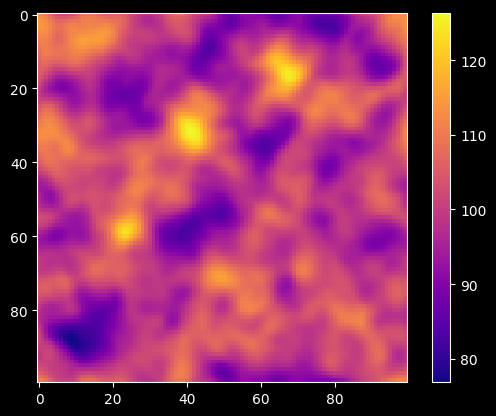

Shard shape: (5, 100, 100, 100)
Partition spec: P(None, 'x', 'y', 'z')
Axis mapping: {'x': 1, 'y': 2, 'z': 3}


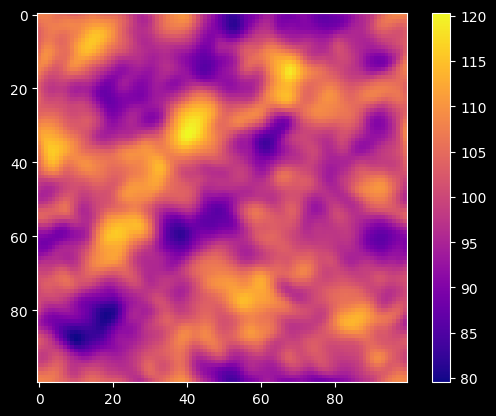

Shard shape: (5, 100, 100, 100)
Partition spec: P(None, 'x', 'y', 'z')
Axis mapping: {'x': 1, 'y': 2, 'z': 3}


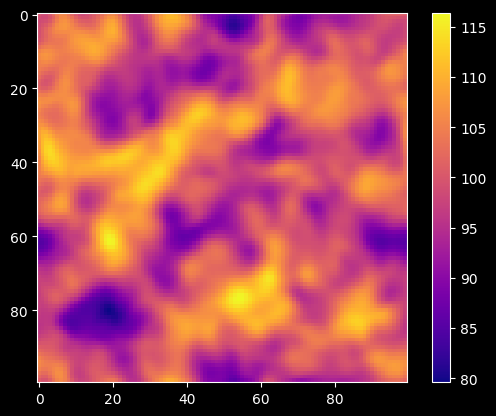

Shard shape: (5, 100, 100, 100)
Partition spec: P(None, 'x', 'y', 'z')
Axis mapping: {'x': 1, 'y': 2, 'z': 3}


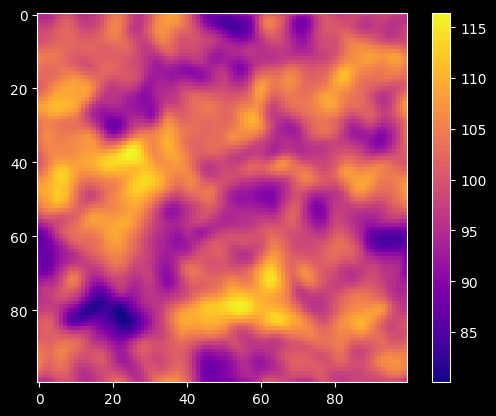

Shard shape: (5, 100, 100, 100)
Partition spec: P(None, 'x', 'y', 'z')
Axis mapping: {'x': 1, 'y': 2, 'z': 3}


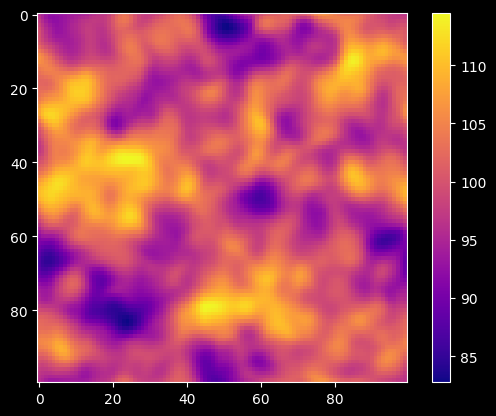

Shard shape: (5, 100, 100, 100)
Partition spec: P(None, 'x', 'y', 'z')
Axis mapping: {'x': 1, 'y': 2, 'z': 3}


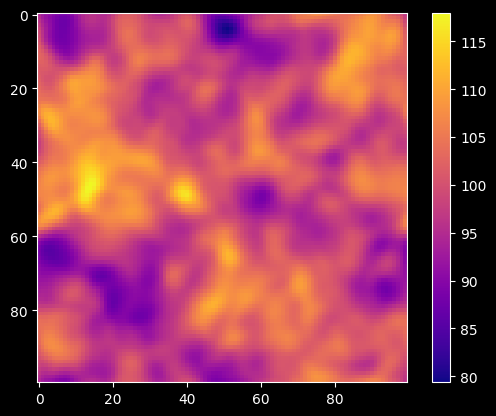

Shard shape: (5, 100, 100, 100)
Partition spec: P(None, 'x', 'y', 'z')
Axis mapping: {'x': 1, 'y': 2, 'z': 3}


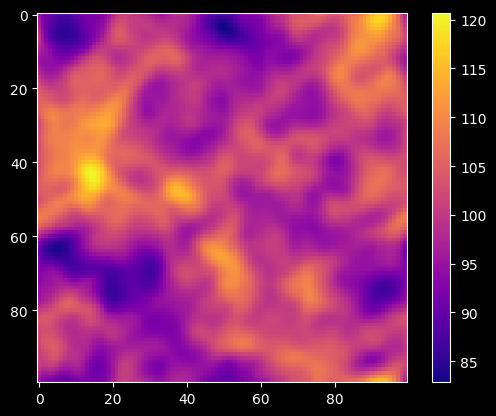

Shard shape: (5, 100, 100, 100)
Partition spec: P(None, 'x', 'y', 'z')
Axis mapping: {'x': 1, 'y': 2, 'z': 3}


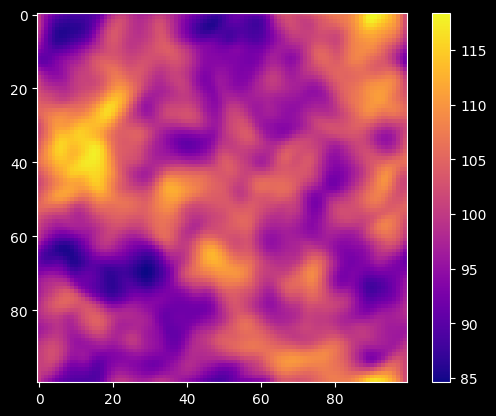

Shard shape: (5, 100, 100, 100)
Partition spec: P(None, 'x', 'y', 'z')
Axis mapping: {'x': 1, 'y': 2, 'z': 3}


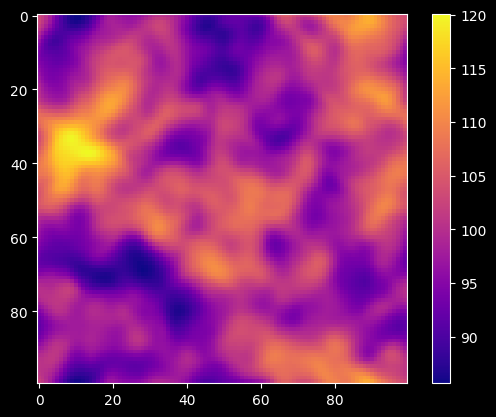

Shard shape: (5, 100, 100, 100)
Partition spec: P(None, 'x', 'y', 'z')
Axis mapping: {'x': 1, 'y': 2, 'z': 3}


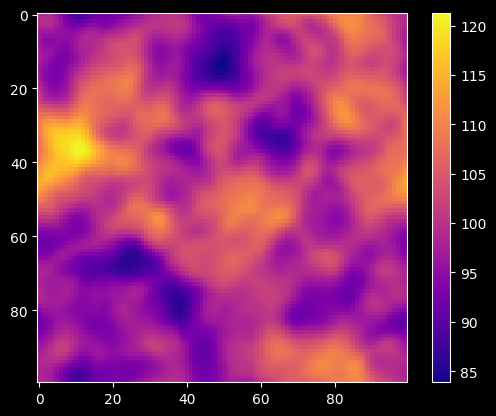

Shard shape: (5, 100, 100, 100)
Partition spec: P(None, 'x', 'y', 'z')
Axis mapping: {'x': 1, 'y': 2, 'z': 3}


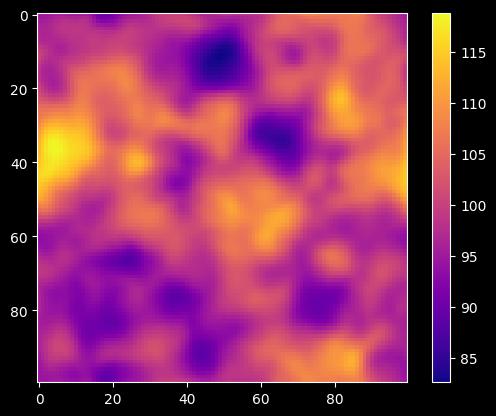

Shard shape: (5, 100, 100, 100)
Partition spec: P(None, 'x', 'y', 'z')
Axis mapping: {'x': 1, 'y': 2, 'z': 3}


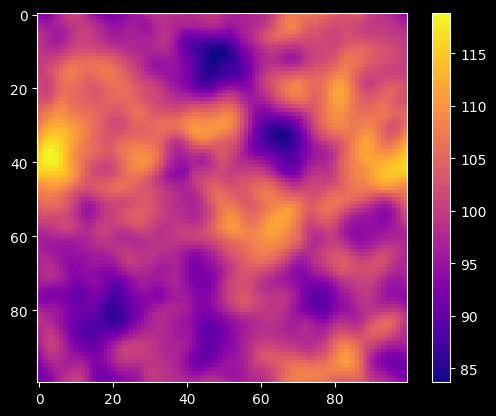

Shard shape: (5, 100, 100, 100)
Partition spec: P(None, 'x', 'y', 'z')
Axis mapping: {'x': 1, 'y': 2, 'z': 3}


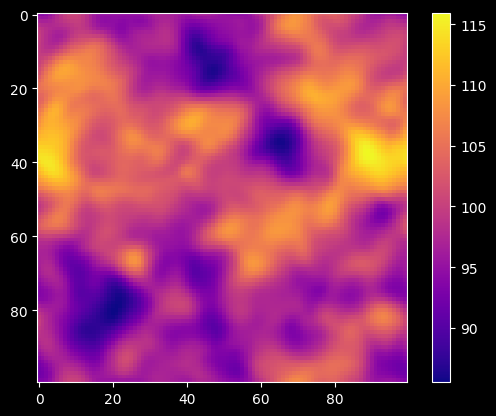

Shard shape: (5, 100, 100, 100)
Partition spec: P(None, 'x', 'y', 'z')
Axis mapping: {'x': 1, 'y': 2, 'z': 3}


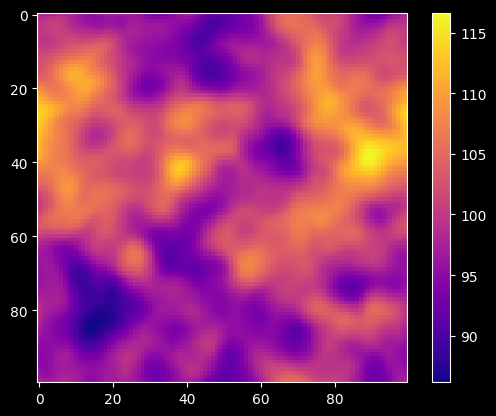

Shard shape: (5, 100, 100, 100)
Partition spec: P(None, 'x', 'y', 'z')
Axis mapping: {'x': 1, 'y': 2, 'z': 3}


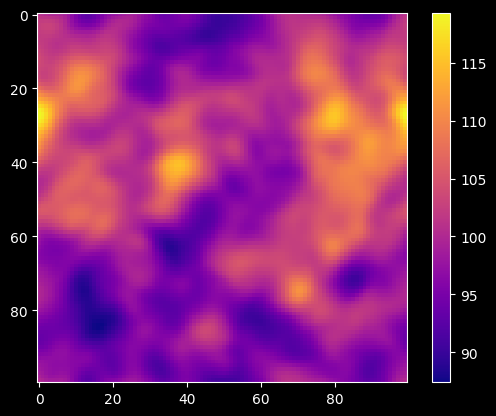

Shard shape: (5, 100, 100, 100)
Partition spec: P(None, 'x', 'y', 'z')
Axis mapping: {'x': 1, 'y': 2, 'z': 3}


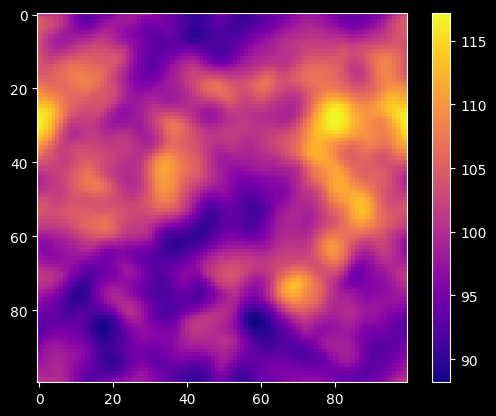

Shard shape: (5, 100, 100, 100)
Partition spec: P(None, 'x', 'y', 'z')
Axis mapping: {'x': 1, 'y': 2, 'z': 3}


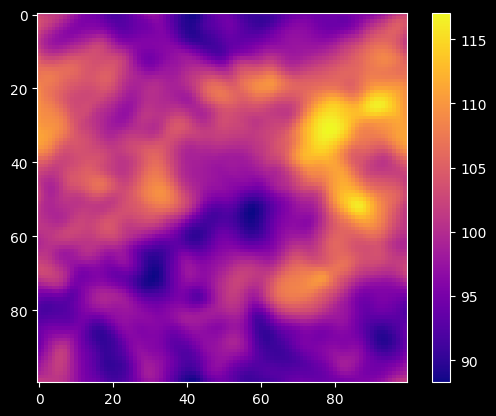

Shard shape: (5, 100, 100, 100)
Partition spec: P(None, 'x', 'y', 'z')
Axis mapping: {'x': 1, 'y': 2, 'z': 3}


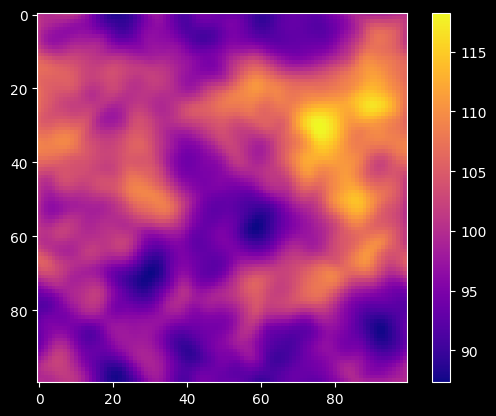

Shard shape: (5, 100, 100, 100)
Partition spec: P(None, 'x', 'y', 'z')
Axis mapping: {'x': 1, 'y': 2, 'z': 3}


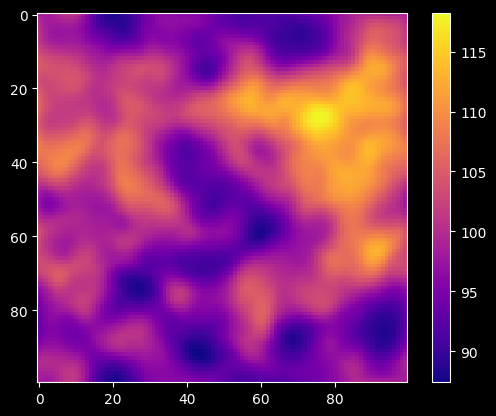

Shard shape: (5, 100, 100, 100)
Partition spec: P(None, 'x', 'y', 'z')
Axis mapping: {'x': 1, 'y': 2, 'z': 3}


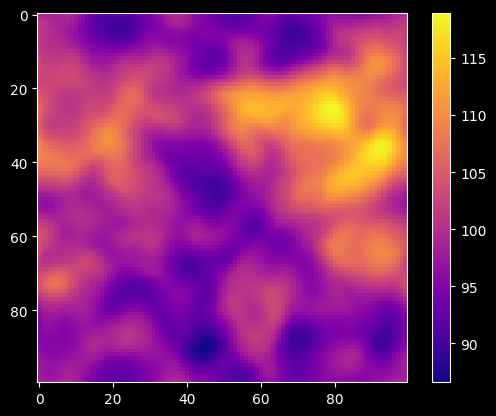

Shard shape: (5, 100, 100, 100)
Partition spec: P(None, 'x', 'y', 'z')
Axis mapping: {'x': 1, 'y': 2, 'z': 3}


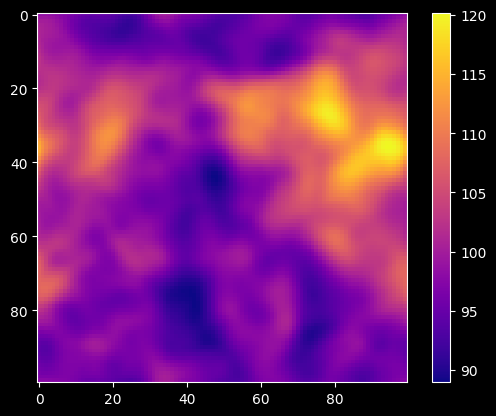

Shard shape: (5, 100, 100, 100)
Partition spec: P(None, 'x', 'y', 'z')
Axis mapping: {'x': 1, 'y': 2, 'z': 3}


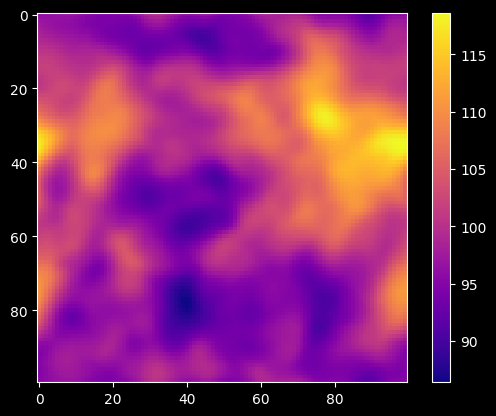

Shard shape: (5, 100, 100, 100)
Partition spec: P(None, 'x', 'y', 'z')
Axis mapping: {'x': 1, 'y': 2, 'z': 3}


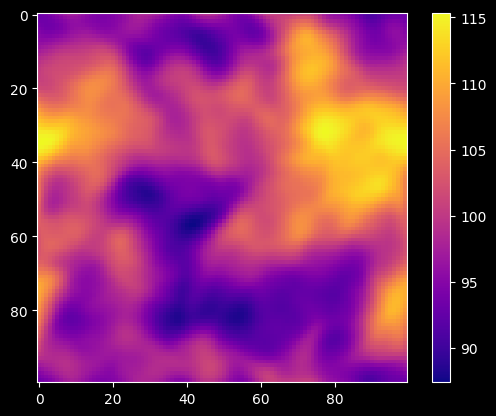

Shard shape: (5, 100, 100, 100)
Partition spec: P(None, 'x', 'y', 'z')
Axis mapping: {'x': 1, 'y': 2, 'z': 3}


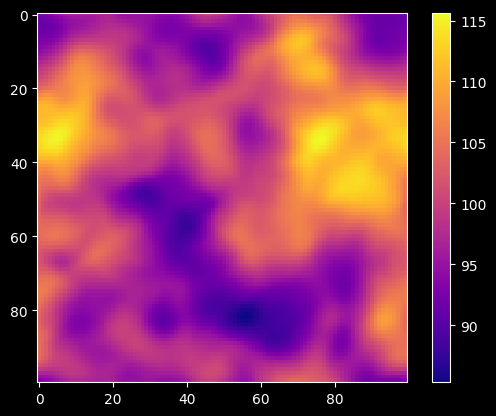

Shard shape: (5, 100, 100, 100)
Partition spec: P(None, 'x', 'y', 'z')
Axis mapping: {'x': 1, 'y': 2, 'z': 3}


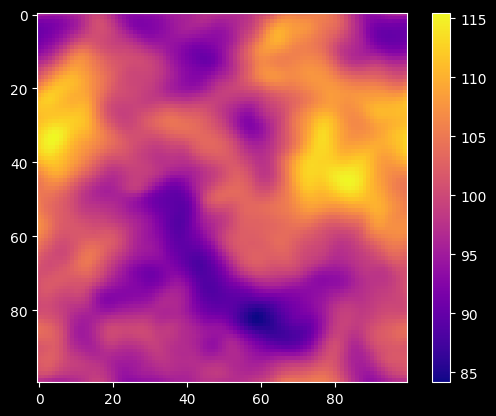

Shard shape: (5, 100, 100, 100)
Partition spec: P(None, 'x', 'y', 'z')
Axis mapping: {'x': 1, 'y': 2, 'z': 3}


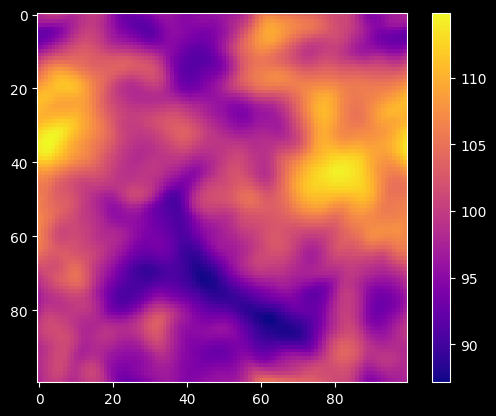

Shard shape: (5, 100, 100, 100)
Partition spec: P(None, 'x', 'y', 'z')
Axis mapping: {'x': 1, 'y': 2, 'z': 3}


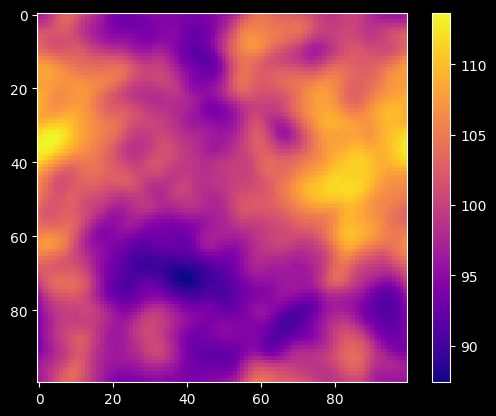

Shard shape: (5, 100, 100, 100)
Partition spec: P(None, 'x', 'y', 'z')
Axis mapping: {'x': 1, 'y': 2, 'z': 3}


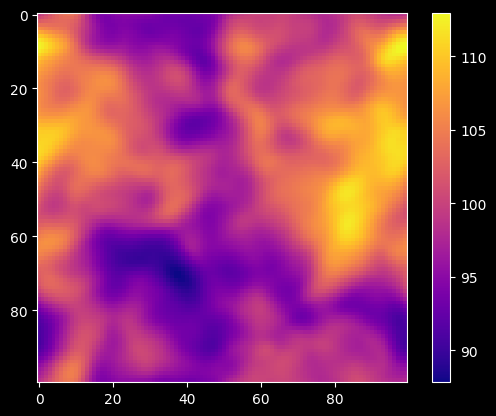

Shard shape: (5, 100, 100, 100)
Partition spec: P(None, 'x', 'y', 'z')
Axis mapping: {'x': 1, 'y': 2, 'z': 3}


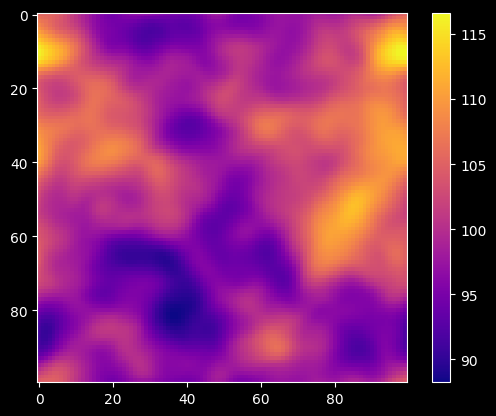

Shard shape: (5, 100, 100, 100)
Partition spec: P(None, 'x', 'y', 'z')
Axis mapping: {'x': 1, 'y': 2, 'z': 3}


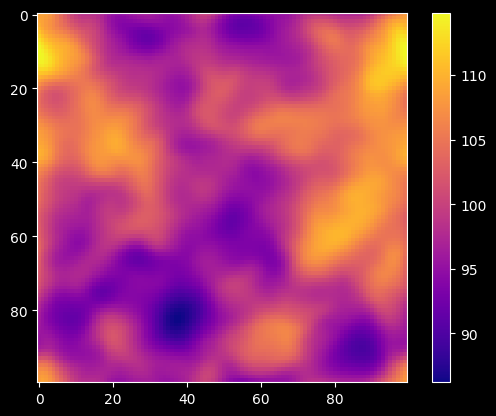

Shard shape: (5, 100, 100, 100)
Partition spec: P(None, 'x', 'y', 'z')
Axis mapping: {'x': 1, 'y': 2, 'z': 3}


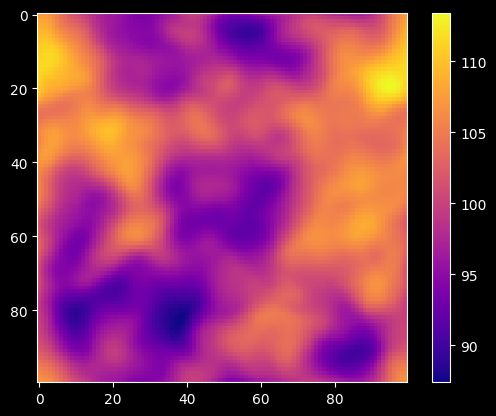

Shard shape: (5, 100, 100, 100)
Partition spec: P(None, 'x', 'y', 'z')
Axis mapping: {'x': 1, 'y': 2, 'z': 3}


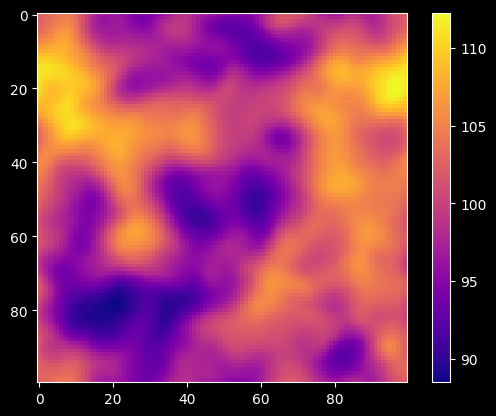

Shard shape: (5, 100, 100, 100)
Partition spec: P(None, 'x', 'y', 'z')
Axis mapping: {'x': 1, 'y': 2, 'z': 3}


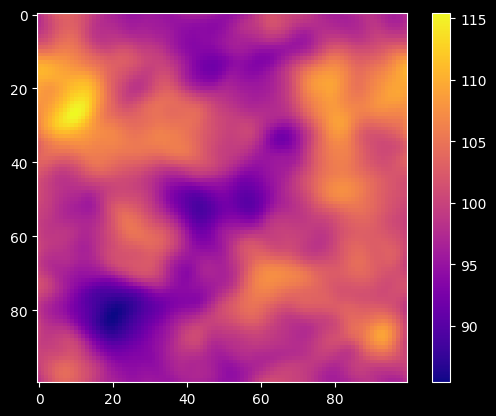

Shard shape: (5, 100, 100, 100)
Partition spec: P(None, 'x', 'y', 'z')
Axis mapping: {'x': 1, 'y': 2, 'z': 3}


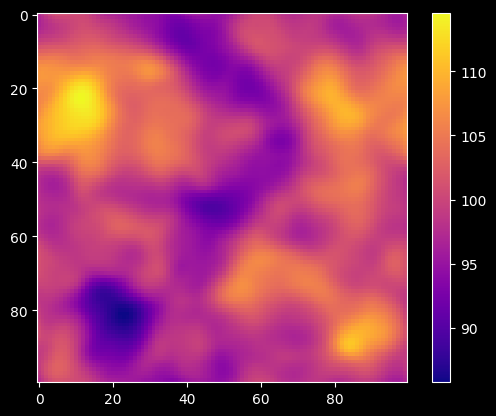

In [70]:
from diffhydro.utils.io import shard_snaps

# Charger tous les 50 steps (matching snapshot_every=50)
for i in range(0, 2000, 50):  # ← Changed from 250 to 50
    imshow(shard_snaps.load_snapshot(hydro, i)[0].sum(axis=2), cmap="plasma")
    colorbar()
    show()

Shard shape: (5, 100, 100, 100)
Partition spec: P(None, 'x', 'y', 'z')
Axis mapping: {'x': 1, 'y': 2, 'z': 3}


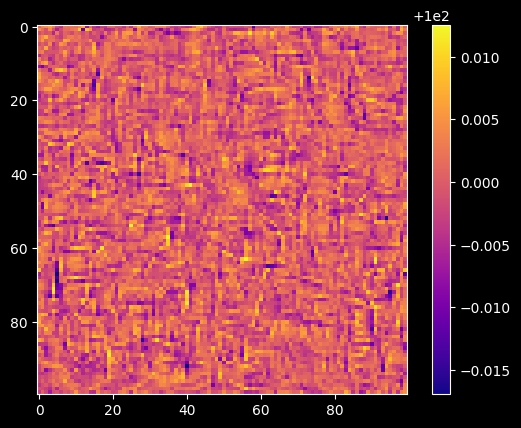

Shard shape: (5, 100, 100, 100)
Partition spec: P(None, 'x', 'y', 'z')
Axis mapping: {'x': 1, 'y': 2, 'z': 3}


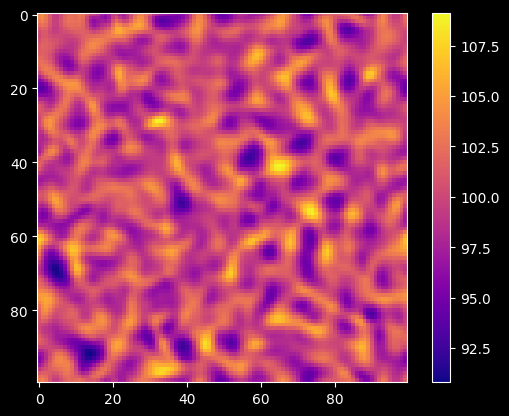

Shard shape: (5, 100, 100, 100)
Partition spec: P(None, 'x', 'y', 'z')
Axis mapping: {'x': 1, 'y': 2, 'z': 3}


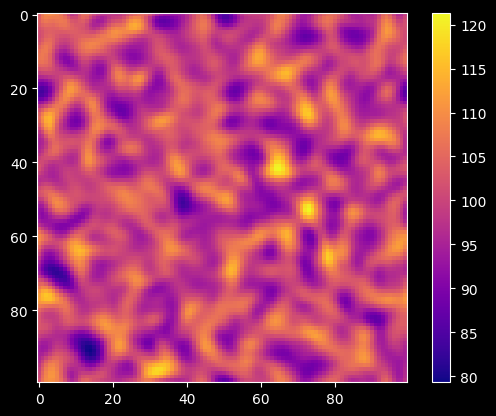

Shard shape: (5, 100, 100, 100)
Partition spec: P(None, 'x', 'y', 'z')
Axis mapping: {'x': 1, 'y': 2, 'z': 3}


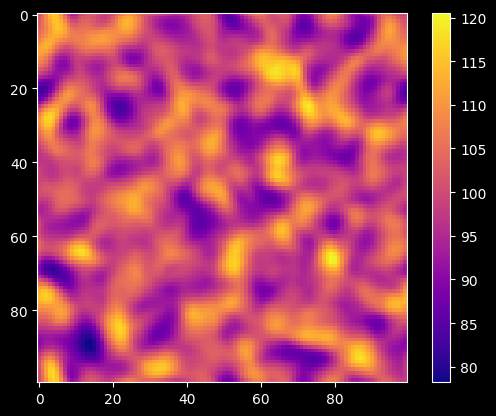

Shard shape: (5, 100, 100, 100)
Partition spec: P(None, 'x', 'y', 'z')
Axis mapping: {'x': 1, 'y': 2, 'z': 3}


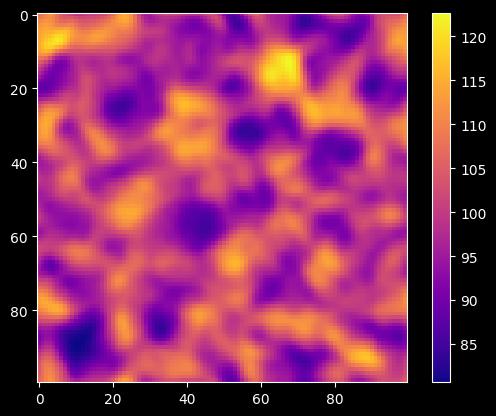

Shard shape: (5, 100, 100, 100)
Partition spec: P(None, 'x', 'y', 'z')
Axis mapping: {'x': 1, 'y': 2, 'z': 3}


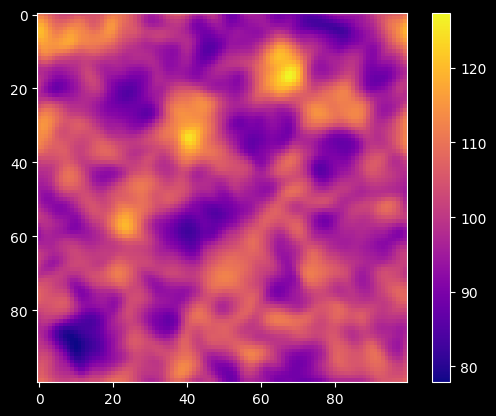

Shard shape: (5, 100, 100, 100)
Partition spec: P(None, 'x', 'y', 'z')
Axis mapping: {'x': 1, 'y': 2, 'z': 3}


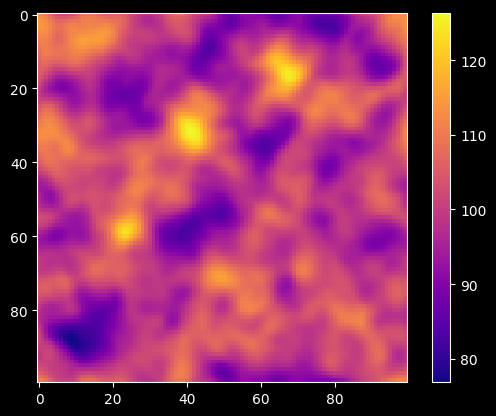

Shard shape: (5, 100, 100, 100)
Partition spec: P(None, 'x', 'y', 'z')
Axis mapping: {'x': 1, 'y': 2, 'z': 3}


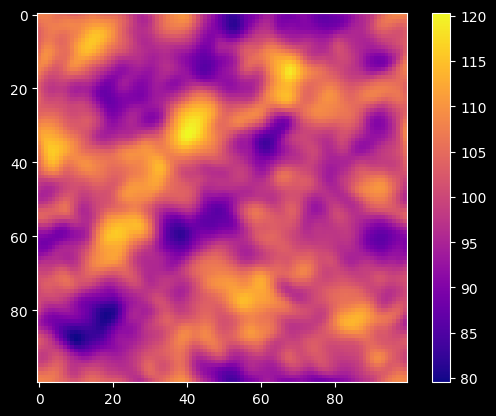

Shard shape: (5, 100, 100, 100)
Partition spec: P(None, 'x', 'y', 'z')
Axis mapping: {'x': 1, 'y': 2, 'z': 3}


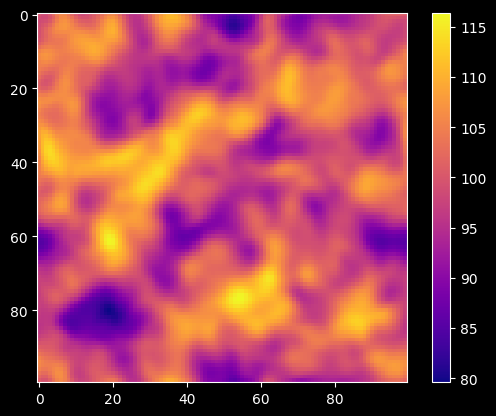

Shard shape: (5, 100, 100, 100)
Partition spec: P(None, 'x', 'y', 'z')
Axis mapping: {'x': 1, 'y': 2, 'z': 3}


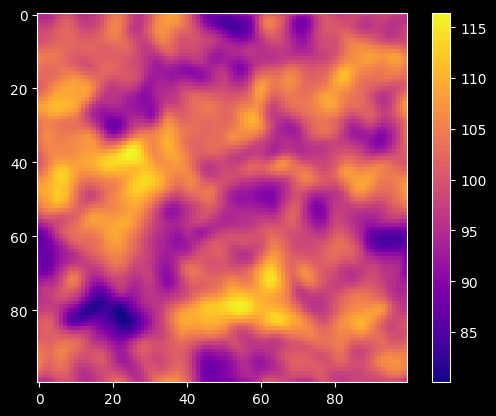

Shard shape: (5, 100, 100, 100)
Partition spec: P(None, 'x', 'y', 'z')
Axis mapping: {'x': 1, 'y': 2, 'z': 3}


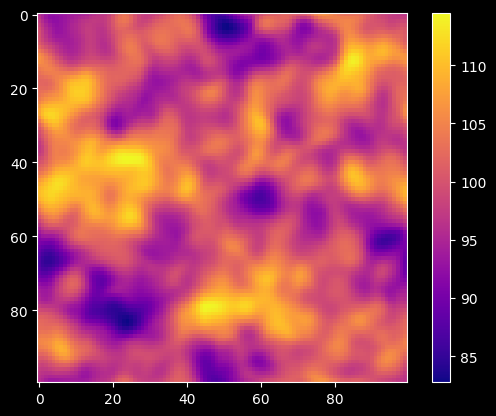

Shard shape: (5, 100, 100, 100)
Partition spec: P(None, 'x', 'y', 'z')
Axis mapping: {'x': 1, 'y': 2, 'z': 3}


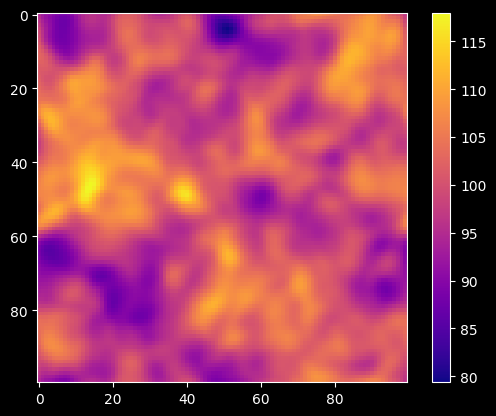

Shard shape: (5, 100, 100, 100)
Partition spec: P(None, 'x', 'y', 'z')
Axis mapping: {'x': 1, 'y': 2, 'z': 3}


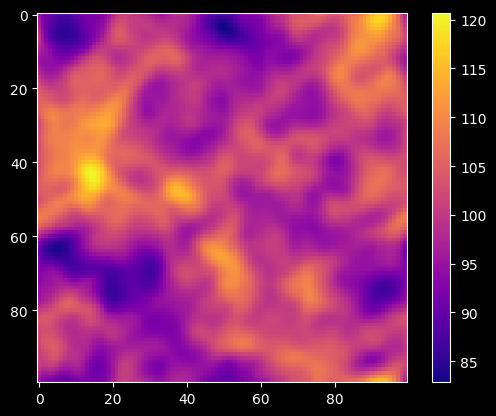

Shard shape: (5, 100, 100, 100)
Partition spec: P(None, 'x', 'y', 'z')
Axis mapping: {'x': 1, 'y': 2, 'z': 3}


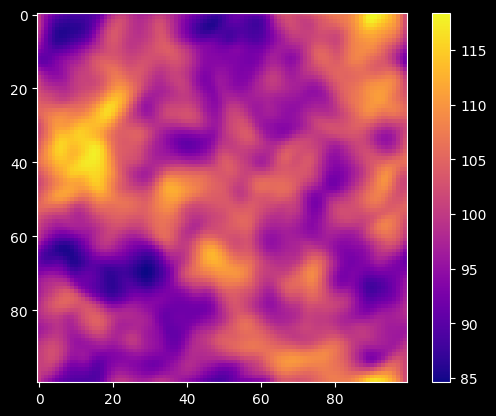

Shard shape: (5, 100, 100, 100)
Partition spec: P(None, 'x', 'y', 'z')
Axis mapping: {'x': 1, 'y': 2, 'z': 3}


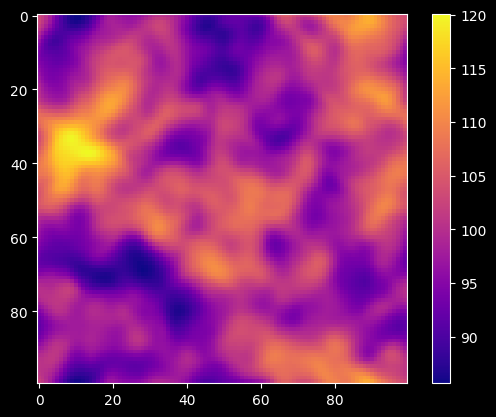

Shard shape: (5, 100, 100, 100)
Partition spec: P(None, 'x', 'y', 'z')
Axis mapping: {'x': 1, 'y': 2, 'z': 3}


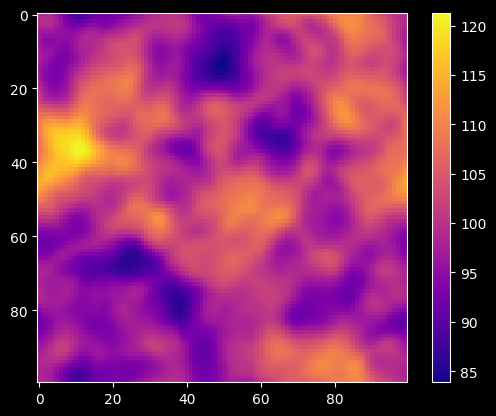

Shard shape: (5, 100, 100, 100)
Partition spec: P(None, 'x', 'y', 'z')
Axis mapping: {'x': 1, 'y': 2, 'z': 3}


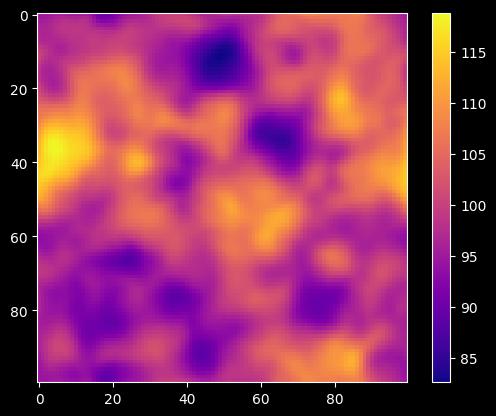

Shard shape: (5, 100, 100, 100)
Partition spec: P(None, 'x', 'y', 'z')
Axis mapping: {'x': 1, 'y': 2, 'z': 3}


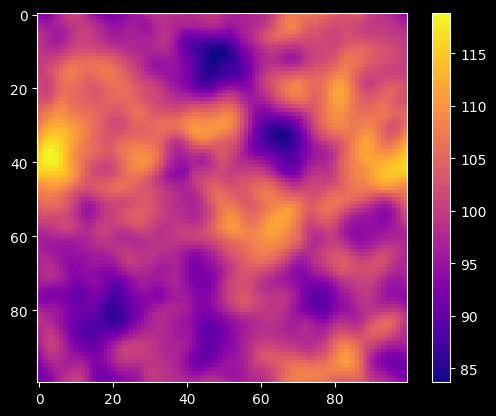

Shard shape: (5, 100, 100, 100)
Partition spec: P(None, 'x', 'y', 'z')
Axis mapping: {'x': 1, 'y': 2, 'z': 3}


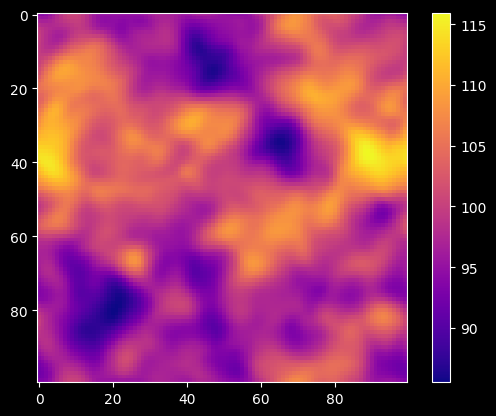

Shard shape: (5, 100, 100, 100)
Partition spec: P(None, 'x', 'y', 'z')
Axis mapping: {'x': 1, 'y': 2, 'z': 3}


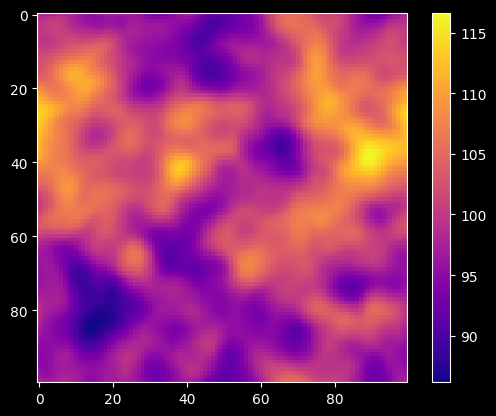

Shard shape: (5, 100, 100, 100)
Partition spec: P(None, 'x', 'y', 'z')
Axis mapping: {'x': 1, 'y': 2, 'z': 3}


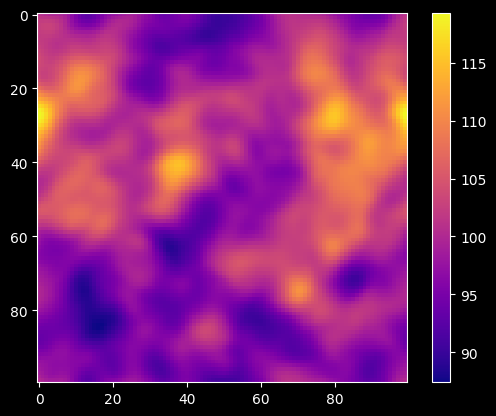

Shard shape: (5, 100, 100, 100)
Partition spec: P(None, 'x', 'y', 'z')
Axis mapping: {'x': 1, 'y': 2, 'z': 3}


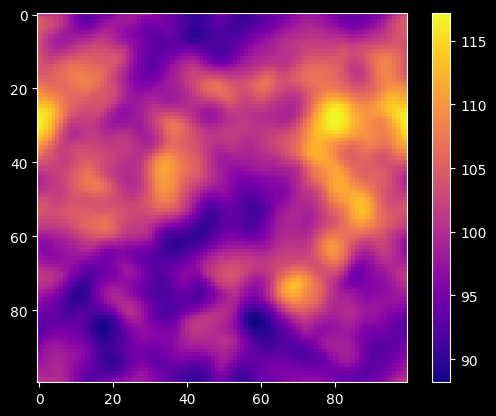

Shard shape: (5, 100, 100, 100)
Partition spec: P(None, 'x', 'y', 'z')
Axis mapping: {'x': 1, 'y': 2, 'z': 3}


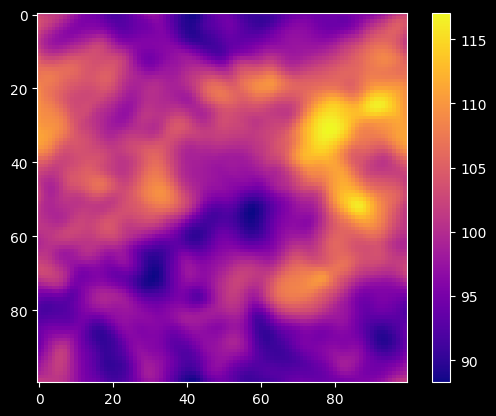

Shard shape: (5, 100, 100, 100)
Partition spec: P(None, 'x', 'y', 'z')
Axis mapping: {'x': 1, 'y': 2, 'z': 3}


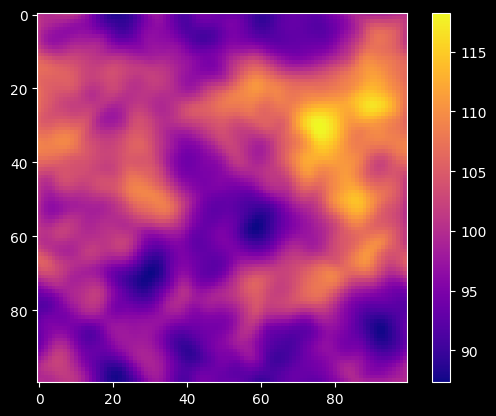

Shard shape: (5, 100, 100, 100)
Partition spec: P(None, 'x', 'y', 'z')
Axis mapping: {'x': 1, 'y': 2, 'z': 3}


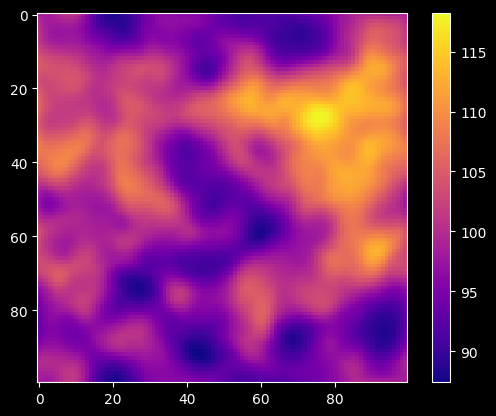

Shard shape: (5, 100, 100, 100)
Partition spec: P(None, 'x', 'y', 'z')
Axis mapping: {'x': 1, 'y': 2, 'z': 3}


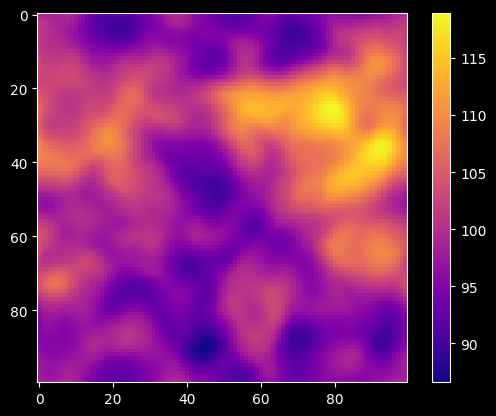

Shard shape: (5, 100, 100, 100)
Partition spec: P(None, 'x', 'y', 'z')
Axis mapping: {'x': 1, 'y': 2, 'z': 3}


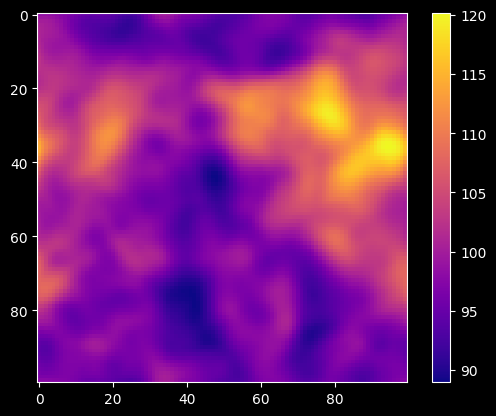

Shard shape: (5, 100, 100, 100)
Partition spec: P(None, 'x', 'y', 'z')
Axis mapping: {'x': 1, 'y': 2, 'z': 3}


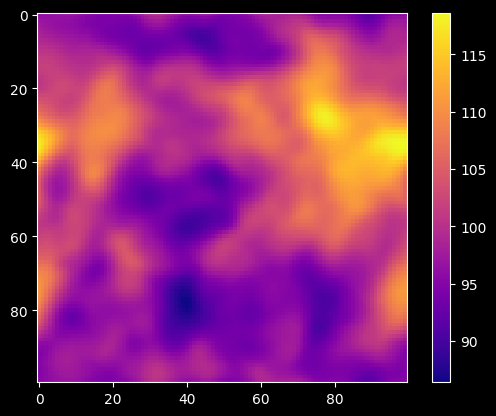

Shard shape: (5, 100, 100, 100)
Partition spec: P(None, 'x', 'y', 'z')
Axis mapping: {'x': 1, 'y': 2, 'z': 3}


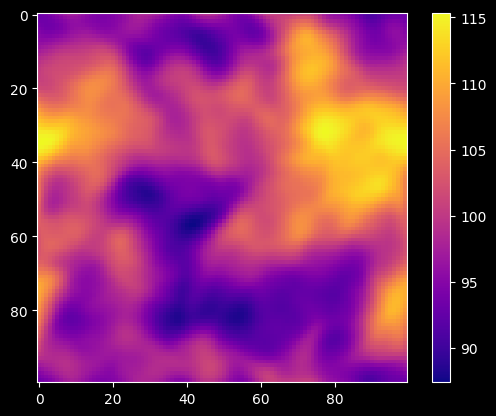

Shard shape: (5, 100, 100, 100)
Partition spec: P(None, 'x', 'y', 'z')
Axis mapping: {'x': 1, 'y': 2, 'z': 3}


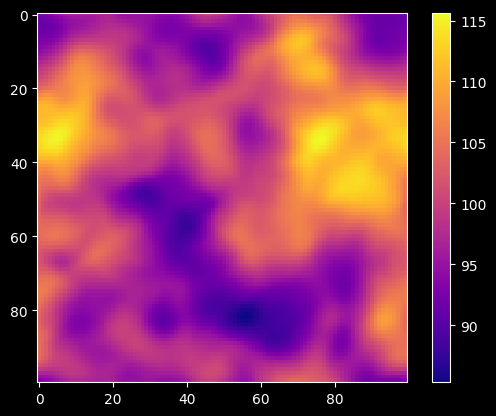

Shard shape: (5, 100, 100, 100)
Partition spec: P(None, 'x', 'y', 'z')
Axis mapping: {'x': 1, 'y': 2, 'z': 3}


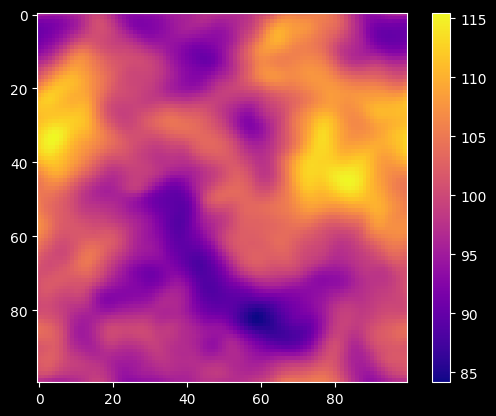

Shard shape: (5, 100, 100, 100)
Partition spec: P(None, 'x', 'y', 'z')
Axis mapping: {'x': 1, 'y': 2, 'z': 3}


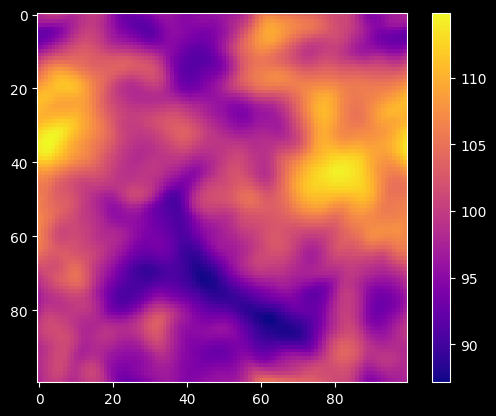

Shard shape: (5, 100, 100, 100)
Partition spec: P(None, 'x', 'y', 'z')
Axis mapping: {'x': 1, 'y': 2, 'z': 3}


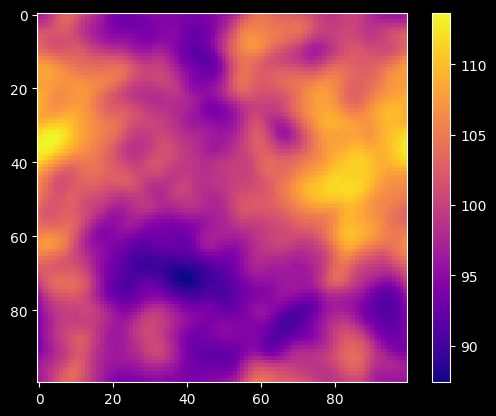

Shard shape: (5, 100, 100, 100)
Partition spec: P(None, 'x', 'y', 'z')
Axis mapping: {'x': 1, 'y': 2, 'z': 3}


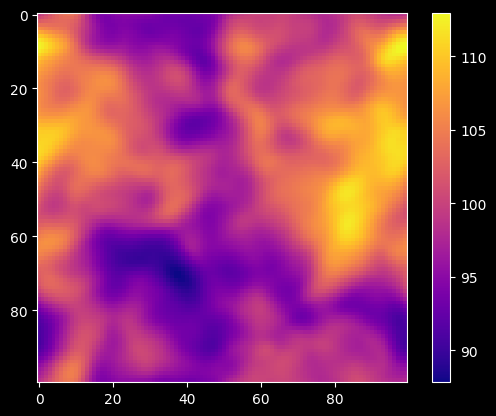

Shard shape: (5, 100, 100, 100)
Partition spec: P(None, 'x', 'y', 'z')
Axis mapping: {'x': 1, 'y': 2, 'z': 3}


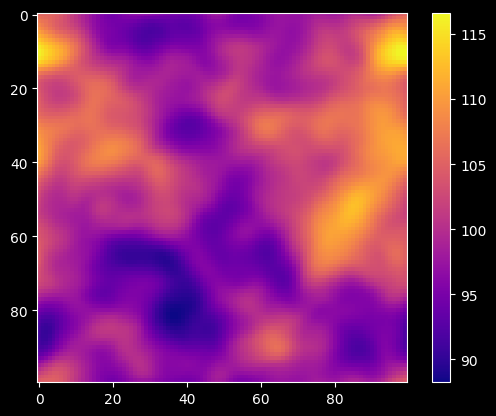

Shard shape: (5, 100, 100, 100)
Partition spec: P(None, 'x', 'y', 'z')
Axis mapping: {'x': 1, 'y': 2, 'z': 3}


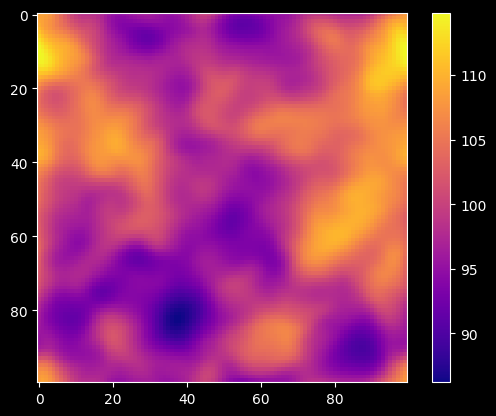

Shard shape: (5, 100, 100, 100)
Partition spec: P(None, 'x', 'y', 'z')
Axis mapping: {'x': 1, 'y': 2, 'z': 3}


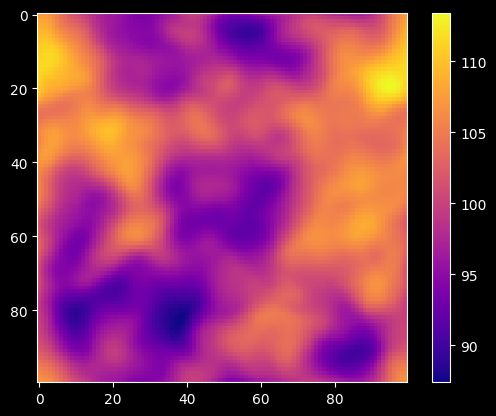

Shard shape: (5, 100, 100, 100)
Partition spec: P(None, 'x', 'y', 'z')
Axis mapping: {'x': 1, 'y': 2, 'z': 3}


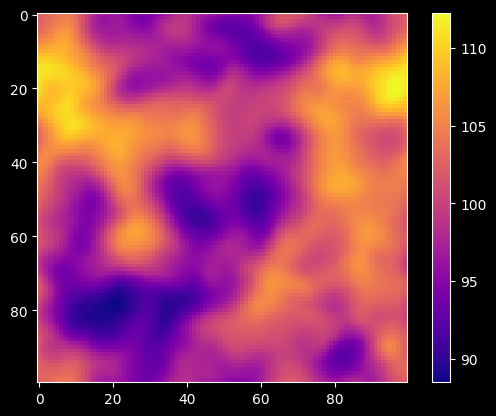

Shard shape: (5, 100, 100, 100)
Partition spec: P(None, 'x', 'y', 'z')
Axis mapping: {'x': 1, 'y': 2, 'z': 3}


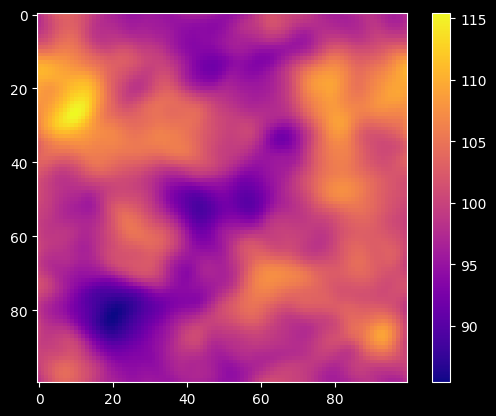

Shard shape: (5, 100, 100, 100)
Partition spec: P(None, 'x', 'y', 'z')
Axis mapping: {'x': 1, 'y': 2, 'z': 3}


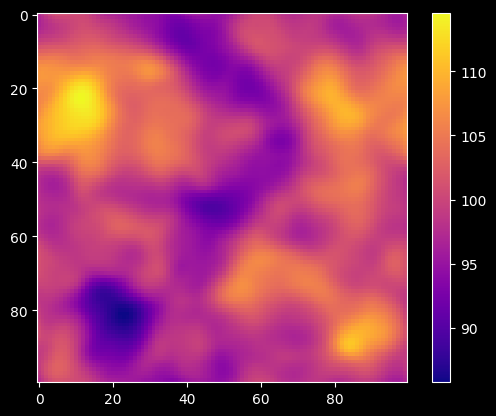

In [71]:
from diffhydro.utils.io import shard_snaps

# Charger tous les 50 steps (matching snapshot_every=50)
for i in range(0, 2000, 50):  # ← Changed from 10000,250 to 2000,50
    imshow(shard_snaps.load_snapshot(hydro, i)[0].sum(axis=2), cmap="plasma")
    colorbar()
    show()

In [72]:
#pretty cute looking! Nice mergers/accretion, stablish blob afterward...

Shard shape: (5, 100, 100, 100)
Partition spec: P(None, 'x', 'y', 'z')
Axis mapping: {'x': 1, 'y': 2, 'z': 3}


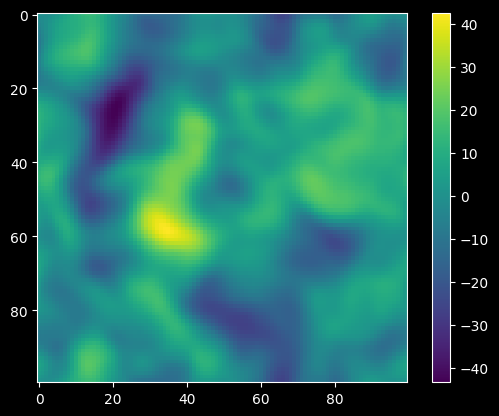

In [73]:
#velocity info
imshow(shard_snaps.load_snapshot(hydro,i)[-3].sum(axis=1))
colorbar()
show()

Shard shape: (5, 100, 100, 100)
Partition spec: P(None, 'x', 'y', 'z')
Axis mapping: {'x': 1, 'y': 2, 'z': 3}


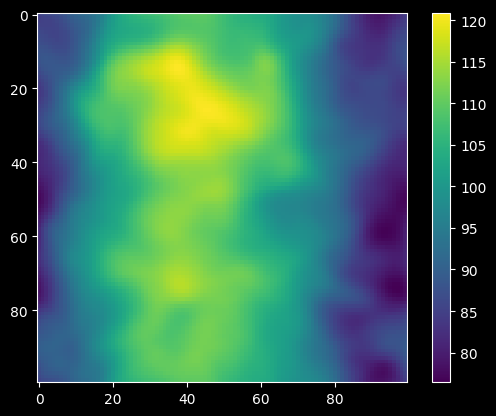

In [74]:
imshow(shard_snaps.load_snapshot(hydro,i)[0].sum(axis=1))
colorbar()
show()

In [ ]:
import imageio
import numpy as np
from matplotlib import cm
from diffhydro.utils.io import shard_snaps

print("Création des GIFs pour tous les snapshots...")

# Paramètres
snapshot_dir = "turb_collapse_big2"
axes_to_plot = [0, 1, 2]  # Trois projections
axis_names = ["axis=0 (XY)", "axis=1 (XZ)", "axis=2 (YZ)"]

# Récupérer le préfixe du snapshot utilisé
snapshot_prefix = hydro.snapshot_prefix  # ← Utilise le préfixe de hydro

# Pour chaque axe de projection
for axis_idx, axis_proj in enumerate(axes_to_plot):
    #print(f"\n⏳ Génération GIF pour {axis_names[axis_idx]}...")
    
    images = []
    
    # Charger tous les snapshots
    for step in range(0, 2000, 50):
        snapshot = shard_snaps.load_snapshot(hydro, step)
        
        # Projeter selon l'axe
        data = snapshot[0].sum(axis=axis_proj)
        
        # Normaliser pour les couleurs
        data_norm = (data - data.min()) / (data.max() - data.min() + 1e-10)
        
        # Appliquer colormap
        colored = cm.plasma(data_norm)
        
        # Convertir en uint8 (0-255)
        img = (colored[:, :, :3] * 255).astype(np.uint8)
        images.append(img)
    
    # Sauvegarder GIF avec titre adapté au préfixe
    gif_name = f"turbulence_collapse_axis{axis_proj}_{snapshot_prefix}.gif"
    # duration est en MILLISECONDES : 40 frames × duration (ms) = temps total (ms)
    # 50ms → 2s total, 100ms → 4s total, 200ms → 8s total
    duration_ms = 1000  # ← CHANGEZ CETTE VALEUR pour ajuster la vitesse
    imageio.mimsave(gif_name, images, duration=duration_ms)
    total_time = len(images) * duration_ms / 1000
    print(f"  ✓ Sauvegardé : {gif_name} (durée totale : {total_time:.1f}s)")

print("\n✅ Les 3 GIFs ont été générés !")

Création des GIFs pour tous les snapshots...

⏳ Génération GIF pour axis=0 (XY)...
Shard shape: (5, 100, 100, 100)
Partition spec: P(None, 'x', 'y', 'z')
Axis mapping: {'x': 1, 'y': 2, 'z': 3}
Shard shape: (5, 100, 100, 100)
Partition spec: P(None, 'x', 'y', 'z')
Axis mapping: {'x': 1, 'y': 2, 'z': 3}
Shard shape: (5, 100, 100, 100)
Partition spec: P(None, 'x', 'y', 'z')
Axis mapping: {'x': 1, 'y': 2, 'z': 3}
Shard shape: (5, 100, 100, 100)
Partition spec: P(None, 'x', 'y', 'z')
Axis mapping: {'x': 1, 'y': 2, 'z': 3}
Shard shape: (5, 100, 100, 100)
Partition spec: P(None, 'x', 'y', 'z')
Axis mapping: {'x': 1, 'y': 2, 'z': 3}
Shard shape: (5, 100, 100, 100)
Partition spec: P(None, 'x', 'y', 'z')
Axis mapping: {'x': 1, 'y': 2, 'z': 3}
Shard shape: (5, 100, 100, 100)
Partition spec: P(None, 'x', 'y', 'z')
Axis mapping: {'x': 1, 'y': 2, 'z': 3}
Shard shape: (5, 100, 100, 100)
Partition spec: P(None, 'x', 'y', 'z')
Axis mapping: {'x': 1, 'y': 2, 'z': 3}
Shard shape: (5, 100, 100, 100)
Parti